### Libraries


In [1]:

import seaborn as sns
import matplotlib.pyplot as plt
import multiprocessing as mp
import random
import warnings
warnings.filterwarnings("ignore")


## Environment description

This exercise aims to implement two popular Temporal Difference Learning algorithms: **SARSA** and **Q-Learning**. We will use several variants of the Grid World problem (a sample world is shown below in Figure 1).

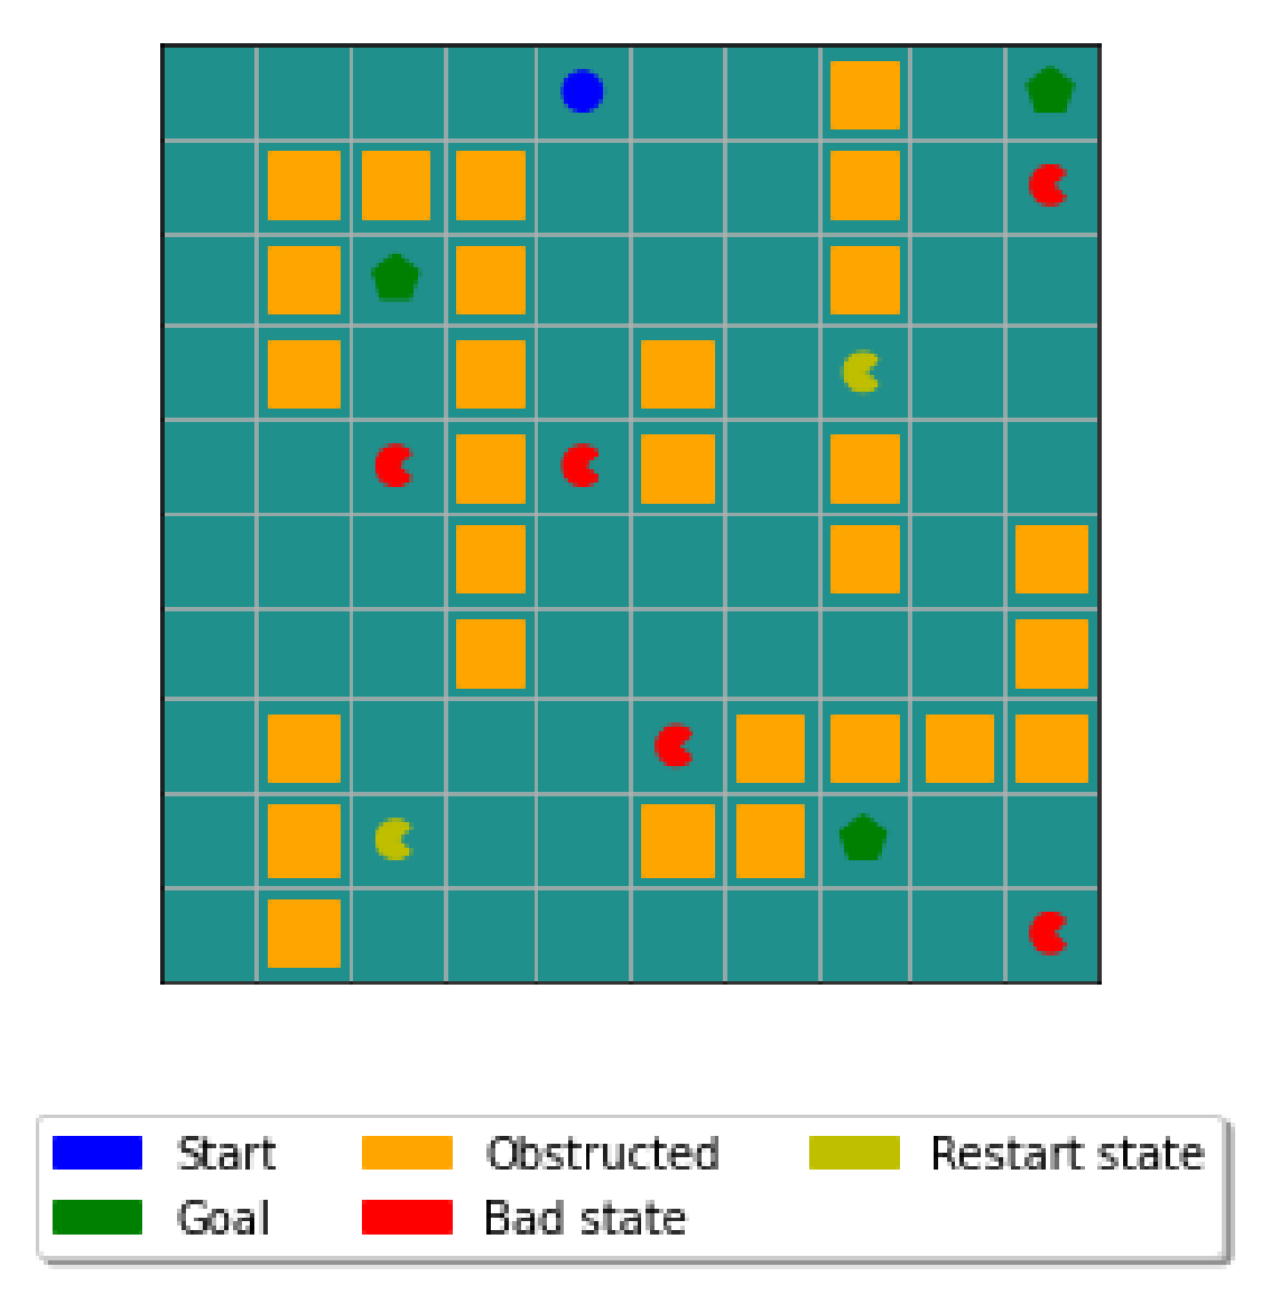

***Figure 1***

This is a grid world with 4 deterministic actions ('up', 'down', 'left', 'right'). The agent transitions to the next state determined by the direction of the action chosen with a probability of $p \in [0, 1]$. We also define a parameter called $b \in [0, 1]$ (Set $b=0.5$ for this assignment). Consider the direction of the action chosen as the agent's “North”. For example, if the action is 'left', it is the agent's North, and the agent's East would be the direction of the action 'up'. Figure 2 provides an illustration of the same. The agent transitions to the state West of the chosen action with probability $(1-p)\times b$, and to the East of the chosen action with probability $(1-p) \times (1-b)$.

 The environment may also have a wind blowing that can push the agent one **additional** cell to the right **after transitioning to the new state** with a probability of 0.4. An episode is terminated either when a goal is reached or when the timesteps exceed 100. Transitions that take you off the grid will not result in any change in state.

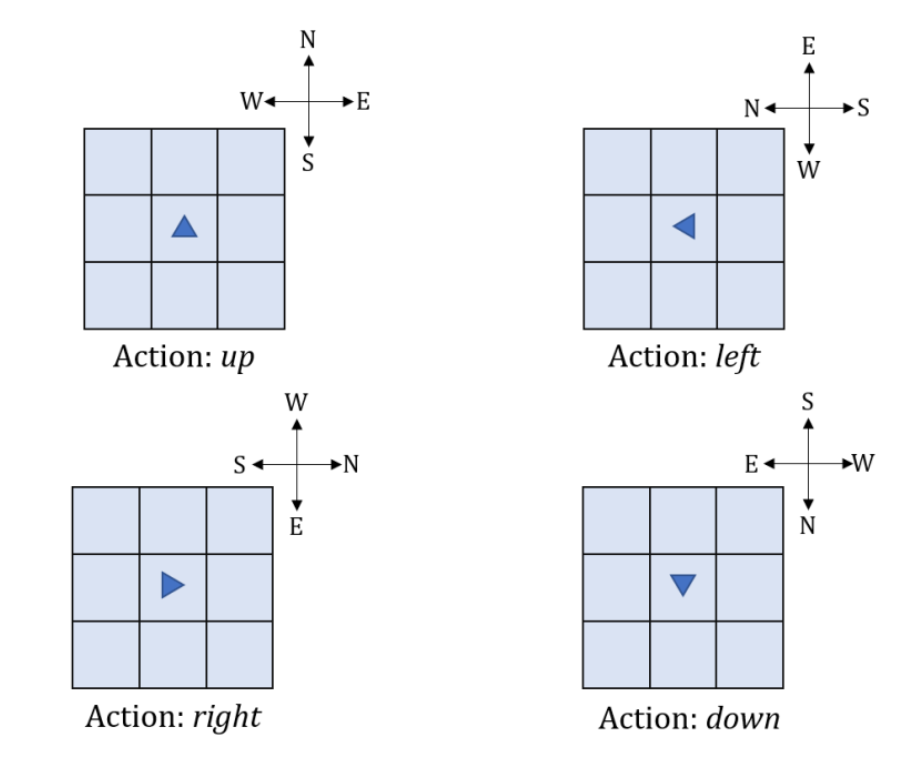

***Figure 2***

The dimensions of the grid are $10 \times 10$. The following types of states exist:

- ***Start state***: The agent starts from this state.
- ***Goal state***: The goal is to reach one of these states. There are 3 goal states in total.

- ***Obstructed state***: These are walls that prevent entry to the respective cells. Transition to these states will not result in any change.

- ***Bad state***: Entry into these states will incur a higher penalty than a normal state.
- ***Restart state***: Entry into these states will incur a very high penalty and will cause agent to teleport to the start state without the episode ending. Once the restart state is reached, no matter what action is chosen, it goes to the start state at the next step.
- ***Normal state***: None of the above. Entry into these states will incur a small penalty.


***Rewards***: -1 for normal states, -100 for restart states, -6 for bad states, +10 for goal states.

## Environment code

The code for the environment can be found below:

In [2]:
from math import floor
import plotly
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

#Converts state number to row_column format
def row_col_to_seq(row_col, num_cols):
    return row_col[:,0] * num_cols + row_col[:,1]

#Converts row_column format to state number
def seq_to_col_row(seq, num_cols):
    r = floor(seq / num_cols)
    c = seq - r * num_cols
    return np.array([[r, c]])

class GridWorld:
    """
    Creates a gridworld object to pass to an RL algorithm.
    Parameters
    ----------
    num_rows : int
        The number of rows in the gridworld.
    num_cols : int
        The number of cols in the gridworld.
    start_state : numpy array of shape (1, 2), np.array([[row, col]])
        The start state of the gridworld (can only be one start state)
    goal_states : numpy arrany of shape (n, 2)
        The goal states for the gridworld where n is the number of goal
        states.
    """
    def __init__(self, num_rows, num_cols, start_state, goal_states, wind = False):
        self.num_rows = num_rows
        self.num_cols = num_cols
        self.start_state = start_state
        self.goal_states = goal_states
        self.obs_states = None
        self.bad_states = None
        self.num_bad_states = 0
        self.p_good_trans = None
        self.bias = None
        self.r_step = None
        self.r_goal = None
        self.r_dead = None
        self.gamma = 1
        self.wind = wind

    # mark obstructed cells
    def add_obstructions(self, obstructed_states=None, bad_states=None, restart_states=None):

        self.obs_states = obstructed_states
        self.bad_states = bad_states
        if bad_states is not None:
            self.num_bad_states = bad_states.shape[0]
        else:
            self.num_bad_states = 0
        self.restart_states = restart_states
        if restart_states is not None:
            self.num_restart_states = restart_states.shape[0]
        else:
            self.num_restart_states = 0

    def add_transition_probability(self, p_good_transition, bias):

        self.p_good_trans = p_good_transition
        self.bias = bias

    def add_rewards(self, step_reward, goal_reward, bad_state_reward=None, restart_state_reward = None):

        self.r_step = step_reward
        self.r_goal = goal_reward
        self.r_bad = bad_state_reward
        self.r_restart = restart_state_reward


    def create_gridworld(self):

        self.num_actions = 4
        self.num_states = self.num_cols * self.num_rows# +1
        self.start_state_seq = row_col_to_seq(self.start_state, self.num_cols)
        self.goal_states_seq = row_col_to_seq(self.goal_states, self.num_cols)

        # rewards structure
        self.R = self.r_step * np.ones((self.num_states, 1))
        #self.R[self.num_states-1] = 0
        self.R[self.goal_states_seq] = self.r_goal

        for i in range(self.num_bad_states):
            if self.r_bad is None:
                raise Exception("Bad state specified but no reward is given")
            bad_state = row_col_to_seq(self.bad_states[i,:].reshape(1,-1), self.num_cols)
            #print("bad states", bad_state)
            self.R[bad_state, :] = self.r_bad
        for i in range(self.num_restart_states):
            if self.r_restart is None:
                raise Exception("Restart state specified but no reward is given")
            restart_state = row_col_to_seq(self.restart_states[i,:].reshape(1,-1), self.num_cols)
            #print("restart_state", restart_state)
            self.R[restart_state, :] = self.r_restart

        # probability model
        if self.p_good_trans == None:
            raise Exception("Must assign probability and bias terms via the add_transition_probability method.")

        self.P = np.zeros((self.num_states,self.num_states,self.num_actions))
        for action in range(self.num_actions):
            for state in range(self.num_states):

                # check if the state is the goal state or an obstructed state - transition to end
                row_col = seq_to_col_row(state, self.num_cols)
                if self.obs_states is not None:
                    end_states = np.vstack((self.obs_states, self.goal_states))
                else:
                    end_states = self.goal_states

                if any(np.sum(np.abs(end_states-row_col), 1) == 0):
                    self.P[state, state, action] = 1

                # else consider stochastic effects of action
                else:
                    for dir in range(-1,2,1):

                        direction = self._get_direction(action, dir)
                        next_state = self._get_state(state, direction)
                        if dir == 0:
                            prob = self.p_good_trans
                        elif dir == -1:
                            prob = (1 - self.p_good_trans)*(self.bias)
                        elif dir == 1:
                            prob = (1 - self.p_good_trans)*(1-self.bias)

                        self.P[state, next_state, action] += prob

                # make restart states transition back to the start state with
                # probability 1
                if self.restart_states is not None:
                    if any(np.sum(np.abs(self.restart_states-row_col),1)==0):
                        next_state = row_col_to_seq(self.start_state, self.num_cols)
                        self.P[state,:,:] = 0
                        self.P[state,next_state,:] = 1

        return self

    def _get_direction(self, action, direction):

        left = [2,3,1,0]
        right = [3,2,0,1]
        if direction == 0:
            new_direction = action
        elif direction == -1:
            new_direction = left[action]
        elif direction == 1:
            new_direction = right[action]
        else:
            raise Exception("getDir received an unspecified case")
        return new_direction

    def _get_state(self, state, direction):

        row_change = [-1,1,0,0]
        col_change = [0,0,-1,1]
        row_col = seq_to_col_row(state, self.num_cols)
        row_col[0,0] += row_change[direction]
        row_col[0,1] += col_change[direction]

        # check for invalid states
        if self.obs_states is not None:
            if (np.any(row_col < 0) or
                np.any(row_col[:,0] > self.num_rows-1) or
                np.any(row_col[:,1] > self.num_cols-1) or
                np.any(np.sum(abs(self.obs_states - row_col), 1)==0)):
                next_state = state
            else:
                next_state = row_col_to_seq(row_col, self.num_cols)[0]
        else:
            if (np.any(row_col < 0) or
                np.any(row_col[:,0] > self.num_rows-1) or
                np.any(row_col[:,1] > self.num_cols-1)):
                next_state = state
            else:
                next_state = row_col_to_seq(row_col, self.num_cols)[0]

        return next_state

    def reset(self):
      return int(self.start_state_seq)

    def step(self, state, action):
        p, r = 0, np.random.random()
        for next_state in range(self.num_states):

            p += self.P[state, next_state, action]

            if r <= p:
                break

        if(self.wind and np.random.random() < 0.4):

          arr = self.P[next_state, :, 3]
          next_next = np.where(arr == np.amax(arr))
          next_next = next_next[0][0]
          return next_next, self.R[next_next]
        else:
          return next_state, self.R[next_state]

    def visualize_gridworld(self):

        # create a 2D grid with empty cells
        grid_world_2D_array = np.ones((self.num_rows, self.num_cols))*ord("E")

        grid_world_2D_array[self.goal_states[:,0],self.goal_states[:,1]]= ord("G")
        grid_world_2D_array[self.obs_states[:,0],self.obs_states[:,1]]= ord("O")
        grid_world_2D_array[self.start_state[:,0],self.start_state[:,1]]= ord("S")
        grid_world_2D_array[self.bad_states[:,0],self.bad_states[:,1]]= ord("B")
        grid_world_2D_array[self.restart_states[:,0],self.restart_states[:,1]]= ord("R")

        grid_world_2D_array_colours = np.ones((self.num_rows, self.num_cols, 3))

        grid_world_2D_array_colours[grid_world_2D_array== ord("G")] =[0,1,0]
        grid_world_2D_array_colours[grid_world_2D_array== ord("O")] =[1,0.65,0]
        grid_world_2D_array_colours[grid_world_2D_array== ord("S")] =[0,0,1]
        grid_world_2D_array_colours[grid_world_2D_array== ord("B")] =[1,0,0]
        grid_world_2D_array_colours[grid_world_2D_array== ord("R")] =[1,1,0]

        fig = px.imshow(grid_world_2D_array_colours)

        state_label = np.empty_like(grid_world_2D_array,
                                    dtype ="<U10")

        state_label[grid_world_2D_array == ord("E")] ="Empty"
        state_label[grid_world_2D_array == ord("G")] ="Goal"
        state_label[grid_world_2D_array == ord("B")] ="Bad"
        state_label[grid_world_2D_array == ord("S")] ="Start"
        state_label[grid_world_2D_array == ord("R")] ="Restart"
        state_label[grid_world_2D_array == ord("O")] ="Obstacle"

        fig.update(data=[{'customdata': state_label,
                          'hovertemplate': 'x: %{x}<br>y: %{y}<br>State: %{customdata}'}])
        # add vertical and horizontal lines
        [fig.add_vline(x=i, line_width=2, line_dash="solid", line_color="Grey") for i in np.arange(-0.5,10)]
        [fig.add_hline(y=i, line_width=2, line_dash="solid", line_color="Grey") for i in np.arange(-0.5,10)]

        # ensure each row and column is numbered/labeled
        fig.update_layout(
            title ="Grid World Vizualization <br>Hover over to a cell for information",
            xaxis = dict(
                tickmode='linear',
                side='top',
                dtick=1),
            yaxis = dict(
                tickmode='linear',
                dtick=1)
        )
        fig.show()


## Environment instantiation

In [3]:
# specify world parameters

# size of the grid
num_cols = 10
num_rows = 10

# coordinates of the cells representing obstruction
obstructions = np.array([[0,7],[1,1],[1,2],[1,3],[1,7],[2,1],[2,3],
                         [2,7],[3,1],[3,3],[3,5],[4,3],[4,5],[4,7],
                         [5,3],[5,7],[5,9],[6,3],[6,9],[7,1],[7,6],
                         [7,7],[7,8],[7,9],[8,1],[8,5],[8,6],[9,1]])

# list of bad states
bad_states = np.array([[1,9],[4,2],[4,4],[7,5],[9,9]])

# list of restart states
restart_states = np.array([[3,7],[8,2]])

# starting position
start_state = np.array([[0,4]])

# list of goal states i.e. terminal states
goal_states = np.array([[0,9],[2,2],[8,7]])

# create the environment's model
gw = GridWorld(num_rows=num_rows,
               num_cols=num_cols,
               start_state=start_state,
               goal_states=goal_states,
               wind = False)

gw.add_obstructions(obstructed_states=obstructions,
                    bad_states=bad_states,
                    restart_states=restart_states)

gw.add_rewards(step_reward=-1,
               goal_reward=10,
               bad_state_reward=-6,
               restart_state_reward=-100)
gw.add_transition_probability(p_good_transition=0.7,
                              bias=0.5)
env = gw.create_gridworld()

## Visualize the grid world

In [4]:
# visualize the grid world configuration
env.visualize_gridworld()

## List environment variables

In [ ]:
print("Number of actions", env.num_actions) #0 -> UP, 1-> DOWN, 2 -> LEFT, 3-> RIGHT
print("Number of states", env.num_states)
print("start state", env.start_state_seq)
print("goal state(s)", env.goal_states_seq)


Number of actions 4
Number of states 100
start state [4]
goal state(s) [ 9 22 87]


The $env.step()$ function takes as arguments the current state and action, and returns the reward and next state. $env.reset()$ resets the environment.

## Tasks
- Implement SARSA and Q-Learning.
- For SARSA, there are a total of $8$ configurations:
  - set $p = 1$
  - wind could take one of two values, `True` or `False`
  - start state could take one of two values: `(0, 4)` or `(3, 6)`
  - exploration strategy could take one of two values: $\epsilon$-greedy or softmax
- For Q-learning, there are a total of $8$ configurations:
  - $p = 1$ or $p = 0.7$
  - set `wind = False`
  - start state could take one of two values: `(0, 4)` or `(3, 6)`
  - exploration strategy could take one of two values: $\epsilon$-greedy or softmax

- For each of the $16$ configurations, determine the best set of hyperparameters (i.e. $ϵ$ in $ϵ$-greedy exploration, temperature $\beta$ in softmax exploration, learning rate $\alpha$, and discount factor $\gamma$) which maximize reward per episode over atleast 100 runs. Plot the following:
  1. Reward curves and the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).
  2. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.
  3. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.
- Try following set of values for each of the hyperparameters, for each of the configurations:

  a. learning rate ($α$) = [0.001, 0.01, 0.1, 1.0]

  b. discount factor ($γ$) = [0.7, 0.8, 0.9, 1.0]

  c. epsilon in $ϵ$-greedy = [0.001, 0.01, 0.05, 0.1] or
  
  Temperature in soft max ($τ$) = [0.01, 0.1, 1, 2]

In [ ]:
np.random.seed(42) #seeding for reproducibility
random.seed(42)
learning_rate=[0.001, 0.01, 0.1, 1.0]
discount_factor= [0.7, 0.8, 0.9, 1.0]
e_greedy = [0.001, 0.01, 0.05, 0.1]
temperature = [0.01, 0.1, 1, 2]

In [ ]:
#Seperate functions for epsilon greedy and softmax to reduce computations
def sarsa_epsilon(env, num_episodes, alpha, gamma, epsilon,tuning=False):
    Q=np.zeros((100,4))
    tot_reward = np.empty(num_episodes)
    # In case of hyper parameter tuning, only rewards in each episode is tracked
    if  not tuning:
    # In non tuning run , tracking of states visited and numer of steps is there
        state_visits = np.zeros(100)
        num_steps=np.empty(num_episodes)
    for episode in range(num_episodes):
        state = env.reset()
        # Choosing the action
        action = np.random.randint(0, 4) if np.random.random() < epsilon else np.argmax(Q[state])
        step=0
        reward_sum=0
        while step<100 and state not in {9,22,87}:
            next_state, reward = env.step(state, action)
            if not tuning:
                state_visits[state] += 1  # Count visits to this state
            #Sampling the best action in the next state
            next_action = np.random.randint(0, 4) if np.random.random() < epsilon else np.argmax(Q[next_state])

            Q[state, action] += alpha * (reward + gamma * Q[next_state, next_action] - Q[state, action])

            state, action = next_state, next_action
            step+=1
            reward_sum+=reward
        tot_reward[episode]=reward_sum
        if not tuning:
           num_steps[episode]=step
    # Returning only rewards if it is tuning else, reward, state visits and number of steps per episode
    if not tuning:
        return Q,tot_reward,num_steps,state_visits
    else:
        return tot_reward



In [ ]:
def sarsa_softmax(env, num_episodes, alpha, gamma, temp,tuning=False):
    Q=np.zeros((100,4))
    tot_reward = np.empty(num_episodes)
    temp1=1/temp
    # In case of hyper parameter tuning, only rewards in each episode is tracked
    if  not tuning:
        # In non tuning run , tracking of states visited and numer of steps is there
        state_visits = np.zeros(100)
        num_steps=np.empty(num_episodes)
    def softmax(Q, state):

        logits = Q[state] * temp1
        logits -= np.max(logits)  # Prevent overflow by shifting values
        exp_logits = np.exp(logits)  # Compute exponentials
        probs = exp_logits / (np.sum(exp_logits) + 1e-8)  # Normalize
        return np.random.choice(4, p=probs)  # Sample action

    for episode in range(num_episodes):
        state = env.reset()
        action = softmax(Q, state)

        step=0
        reward_sum=0
        while step<100 and state not in {9,22,87}:
            next_state, reward = env.step(state, action)
            if not tuning:
                state_visits[state] += 1  # Count visits to this state
            next_action = softmax(Q, next_state)
            # To reduce memory access, Q value saved in qnow
            qnow=Q[state,action]
            Q[state, action] =  qnow + alpha * (reward + gamma * Q[next_state, next_action] - qnow)

            state, action = next_state, next_action
            reward_sum+=reward
            step+=1
        tot_reward[episode]=reward_sum
        if not tuning:
            num_steps[episode]=step
    # Returning only rewards if it is tuning else, reward, state visits and number of steps per episode
    if not tuning:
        return Q,tot_reward,num_steps,state_visits
    else:
        return tot_reward


In [ ]:

def q_learning_epsilon(env, num_episodes, alpha, gamma, epsilon,tuning=False):
    Q=np.zeros((100,4))
    tot_reward = np.empty(num_episodes)
    # In case of hyper parameter tuning, only rewards in each episode is tracked
    if  not tuning:
        # In non tuning run , tracking of states visited and numer of steps is there
        state_visits = np.zeros(100)
        num_steps=np.empty(num_episodes)
    for episode in range(num_episodes):
        state = env.reset()
        step = 0
        reward_sum=0

        while step < 100 and state not in {9,22,87}:
            action = np.random.randint(0, 4) if np.random.random() < epsilon else np.argmax(Q[state])
            next_state, reward = env.step(state, action)
            if not tuning:
                state_visits[state] += 1  # Count visits to this state

            # Q-learning update rule (off-policy)
            best_next_action = Q[next_state].argmax()  # Select best action for next state
            # To reduce memory access, Q value saved in qnow
            qnow=Q[state,action]
            Q[state, action] = qnow + alpha * (reward + gamma * Q[next_state, best_next_action] - qnow)

            state = next_state  # Move to next state

            step += 1  # Increment step counter
            reward_sum+=reward
        tot_reward[episode]=reward_sum
        if not tuning:
           num_steps[episode]=step
    # Returning only rewards if it is tuning else, reward, state visits and number of steps per episode
    if not tuning:
        return Q,tot_reward,num_steps,state_visits
    else:
        return tot_reward

In [ ]:

def q_learning_softmax(env, num_episodes, alpha, gamma, temp,tuning=False):
    Q=np.zeros((100,4))
    tot_reward = np.empty(num_episodes)
    temp1=1/temp
    # In case of hyper parameter tuning, only rewards in each episode is tracked
    if  not tuning:
        # In non tuning run , tracking of states visited and numer of steps is there
        state_visits = np.zeros(100)
        num_steps=np.empty(num_episodes)
    def softmax(Q, state):
        logits = Q[state] * temp1
        logits -= np.max(logits)  # Prevent overflow by shifting values
        exp_logits = np.exp(logits)  # Compute exponentials
        probs = exp_logits / (np.sum(exp_logits) + 1e-8)  # Normalize
        return np.random.choice(4, p=probs)  # Sample action
    for episode in range(num_episodes):
        state = env.reset()
        step = 0
        reward_sum=0
        while step < 100 and state not in {9,22,87}:
            action = softmax(Q, state)  # Select action using epsilon-greedy
            next_state, reward = env.step(state, action)
            if not tuning:
                state_visits[state] += 1  # Count visits to this state
            # Q-learning update rule (off-policy)
            best_next_action = Q[next_state].argmax()  # Select best action for next state
            # To reduce memory access, Q value saved in qnow
            qnow=Q[state,action]
            Q[state, action] = qnow + alpha * (reward + gamma * Q[next_state, best_next_action] - qnow)
            reward_sum+=reward
            state = next_state  # Move to next state
            step += 1  # Increment step counter
        tot_reward[episode]=reward_sum
        if not tuning:
            num_steps[episode]=step
    # Returning only rewards if it is tuning else, reward, state visits and number of steps per episode
    if not tuning:
        return Q,tot_reward,num_steps,state_visits
    else:
        return tot_reward

## Configurations

There are total 16 configurations 8 each for SARSA and Q-Learning)

###  Configuration id  **1**

#### Configuration Parameters
Learning algorithm = SARSA

Wind = True

Start State = (0, 4)

Value of $p$ =1

Exploration strategy = ϵ -greedy

Train the agent

In [ ]:


env.start_state=np.array([[0,4]])
env.p_good_trans=1
env.wind=True

def parallel_sarsa(env, num_episodes, alpha, gamma, epsilon, num_runs,tuning):
    """Parallel execution of SARSA runs using multiprocessing."""
    with mp.Pool(mp.cpu_count()) as pool:
        results = pool.starmap(sarsa_epsilon, [(env, num_episodes, alpha, gamma, epsilon,tuning)] * num_runs)
    #To return results in case of non tuning run
    if not tuning:
        return results[0][0],results[0][1],results[0][2],results[0][3]
    else:
        return np.mean(results, axis=0)  # Average across runs


# Hyperparameters
num_runs = 100
coarse_episodes = 170
fine_tune_episodes = 1700
top_k_ratio = 0.1

# Store results from coarse search
top_configs = []

# Coarse Search to filter obviously bad configurations
for alpha in learning_rate:
    for gamma in discount_factor:
        for epsilon in e_greedy:
            reward = parallel_sarsa(env, coarse_episodes, alpha, gamma, epsilon, num_runs,True)
            reward_cumulative = np.sum(reward)
            top_configs.append((reward_cumulative, alpha, gamma, epsilon))

# Sort and keep the top 10%
top_configs = np.array(top_configs)
top_configs = top_configs[top_configs[:, 0].argsort()[::-1]][:int(len(top_configs) * top_k_ratio)]

# Fine-Tuning on Best Configurations
max_reward, max_alpha, max_gamma, max_epsilon =-float('inf'), 0, 0, 0

for reward_cumulative, alpha, gamma, epsilon in top_configs:
    reward = parallel_sarsa(env, fine_tune_episodes, alpha, gamma, epsilon, num_runs,True)
    reward_cumulative = np.sum(reward)

    if reward_cumulative > max_reward:
        max_reward, max_alpha, max_gamma, max_epsilon = reward_cumulative, alpha, gamma, epsilon

print("Best Parameters:", max_alpha, max_gamma, max_epsilon)

num_episodes=10000
Q,reward,steps,state_visits = parallel_sarsa(env, num_episodes, max_alpha, max_gamma,max_epsilon,1,False)  # Train SARSA

Best Parameters: 0.1 0.9 0.001


1. Plot reward curves (during the training phase with the best hyperparameters).

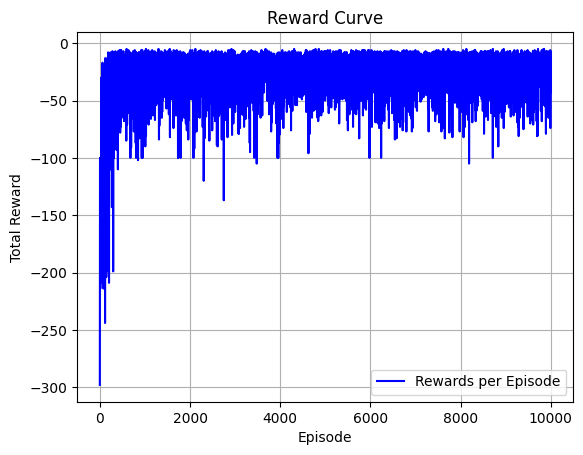

In [ ]:


plt.plot(reward, label="Rewards per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Curve")
plt.legend()
plt.grid()
plt.show()


2. Plot the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).

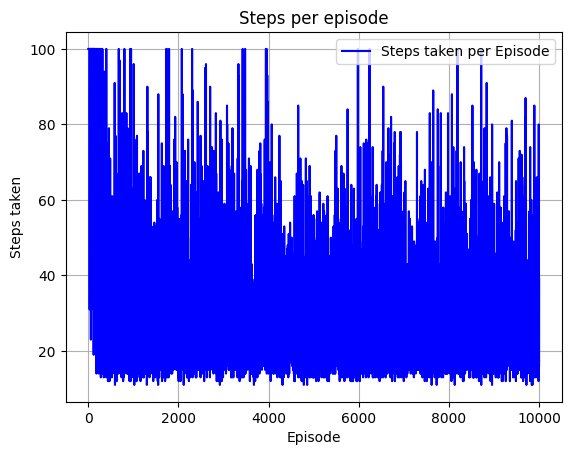

In [ ]:

plt.plot(steps, label="Steps taken per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Steps taken")
plt.title("Steps per episode")
plt.legend()
plt.grid()
plt.show()


3. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.

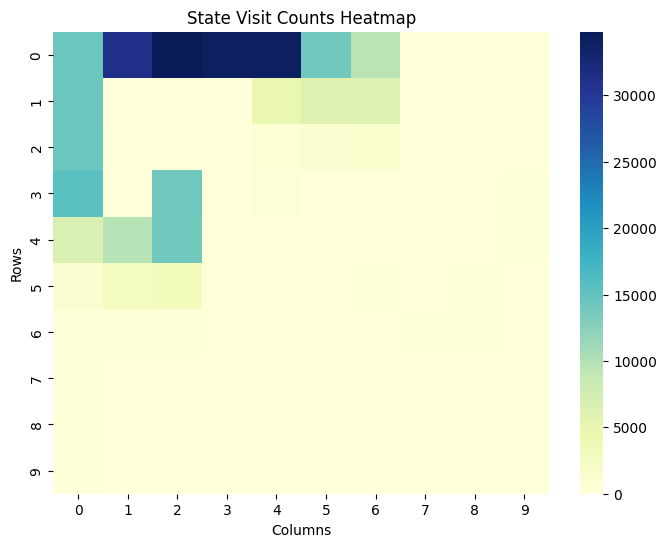

In [ ]:

grid_visits = state_visits.reshape((env.num_rows, env.num_cols))
plt.figure(figsize=(8, 6))
sns.heatmap(grid_visits, cmap="YlGnBu", annot=False, fmt="d")
plt.title("State Visit Counts Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()



4. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.

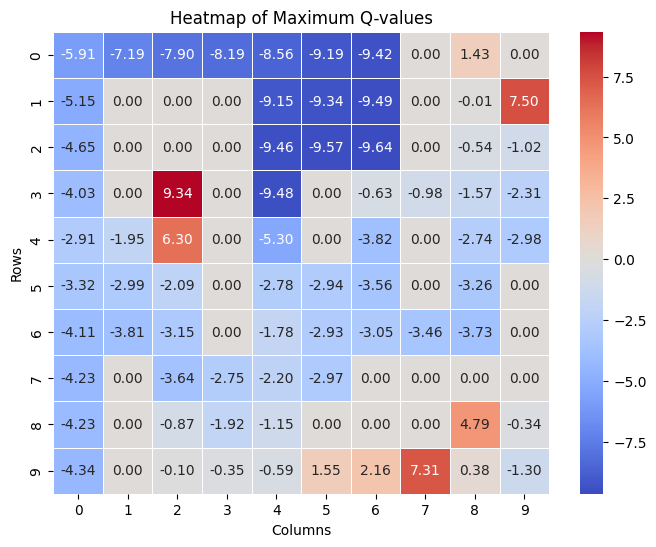

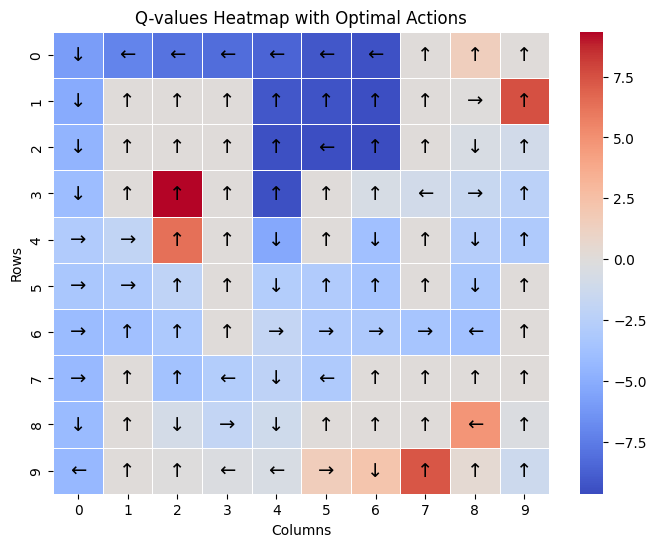

In [ ]:

# Get optimal action for each state (argmax over actions)
optimal_actions = np.argmax(Q, axis=1)

# Compute maximum Q-value per state
max_Q_values = np.max(Q, axis=1)

# Reshape into grid
Q_grid = max_Q_values.reshape((env.num_rows, env.num_cols))
optimal_action_grid = optimal_actions.reshape((env.num_rows, env.num_cols))

plt.figure(figsize=(8, 6))
sns.heatmap(Q_grid, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Maximum Q-values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


# Define action symbols
action_symbols = {0: "↑", 3: "→", 1: "↓", 2: "←"}

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Q_grid, cmap="coolwarm", annot=False, linewidths=0.5)

# Overlay optimal actions
for i in range(env.num_rows):
    for j in range(env.num_cols):
        action = optimal_action_grid[i, j]
        ax.text(j + 0.5, i + 0.5, action_symbols[action], ha="center", va="center", color="black", fontsize=14)

plt.title("Q-values Heatmap with Optimal Actions")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

###  Configuration id 2

#### Configuration Parameters
Learning algorithm = SARSA

Wind = True

Start State = (0,4)

Value of $p$ = 1

Exploration strategy = softmax

Train the agent

In [ ]:

env.start_state=np.array([[0,4]])
env.p_good_trans=1
env.wind=True

def parallel_sarsa(env, num_episodes, alpha, gamma,temp, num_runs,tuning):
    """Parallel execution of SARSA runs using multiprocessing."""
    with mp.Pool(mp.cpu_count()) as pool:
         results = pool.starmap(sarsa_softmax, [(env, num_episodes, alpha, gamma, temp,tuning)] * num_runs)
    if not tuning:
        return results[0][0],results[0][1],results[0][2],results[0][3]
    else:
        return np.mean(results, axis=0)  # Average across runs

# Hyperparameters
num_runs = 100
coarse_episodes = 170
fine_tune_episodes = 1700
top_k_ratio = 0.1

# Store results from coarse search
top_configs = []

# Coarse Search to filter obviously bad configurations
for alpha in learning_rate:
    for gamma in discount_factor:
        for temp in temperature:
            reward = parallel_sarsa(env, coarse_episodes, alpha, gamma,temp, num_runs,True)
            reward_cumulative = np.sum(reward)
            top_configs.append((reward_cumulative, alpha, gamma,temp))

# Sort and keep the top 10%
top_configs = np.array(top_configs)
top_configs = top_configs[top_configs[:, 0].argsort()[::-1]][:int(len(top_configs) * top_k_ratio)]

# Fine-Tuning on Best Configurations
max_reward, max_alpha, max_gamma, max_temp = -float('inf'), 0, 0, 0

for reward_cumulative, alpha, gamma, temp in top_configs:
    reward = parallel_sarsa(env, fine_tune_episodes, alpha, gamma,temp, num_runs,True)
    reward_cumulative = np.sum(reward)

    if reward_cumulative > max_reward:
        max_reward, max_alpha, max_gamma, max_temp = reward_cumulative, alpha, gamma,temp

print("Best Parameters:", max_alpha, max_gamma,max_temp)

num_episodes=10000
Q,reward,steps,state_visits = parallel_sarsa(env, num_episodes, max_alpha, max_gamma,max_temp,1,False)  # Train SARSA



Best Parameters: 1.0 1.0 0.01


1. Plot reward curves (during the training phase with the best hyperparameters).

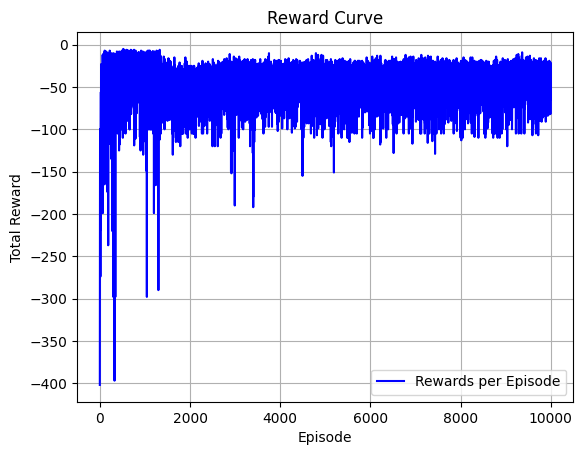

In [ ]:

plt.plot(reward, label="Rewards per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Curve")
plt.legend()
plt.grid()
plt.show()

2. Plot the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).

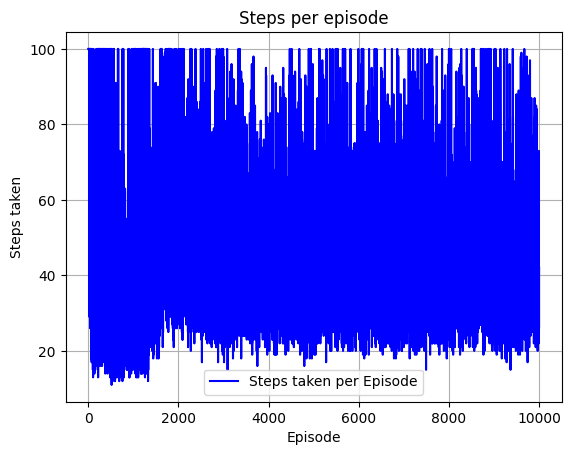

In [ ]:

plt.plot(steps, label="Steps taken per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Steps taken")
plt.title("Steps per episode")
plt.legend()
plt.grid()
plt.show()

3. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.

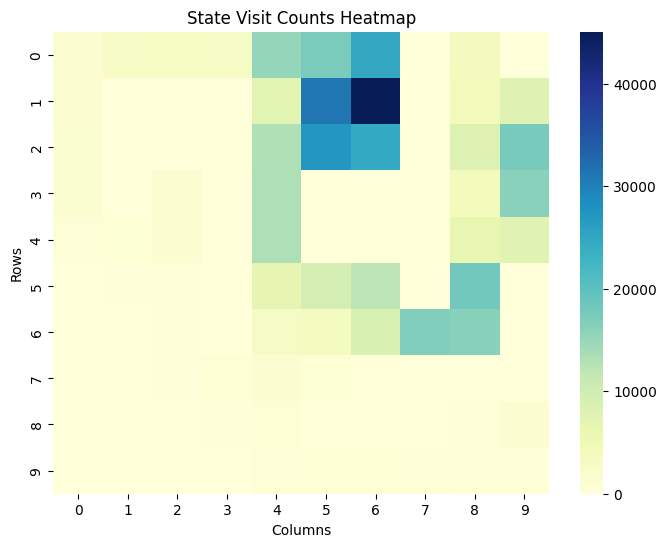

In [ ]:

grid_visits = state_visits.reshape((env.num_rows, env.num_cols))
plt.figure(figsize=(8, 6))
sns.heatmap(grid_visits, cmap="YlGnBu", annot=False, fmt="d")
plt.title("State Visit Counts Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

4. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.

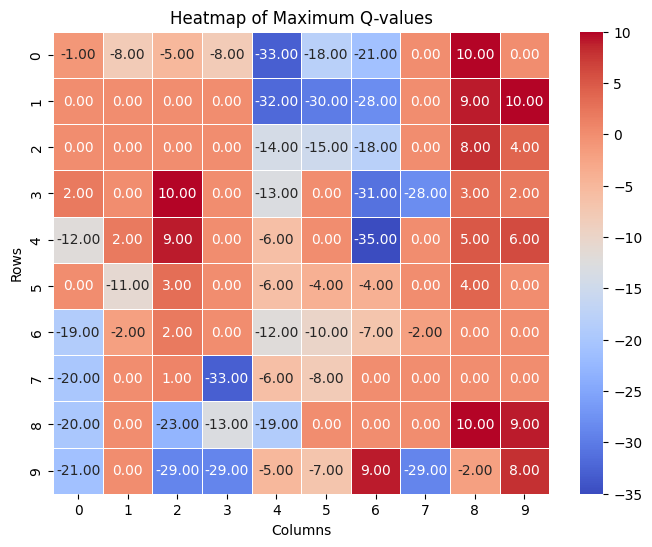

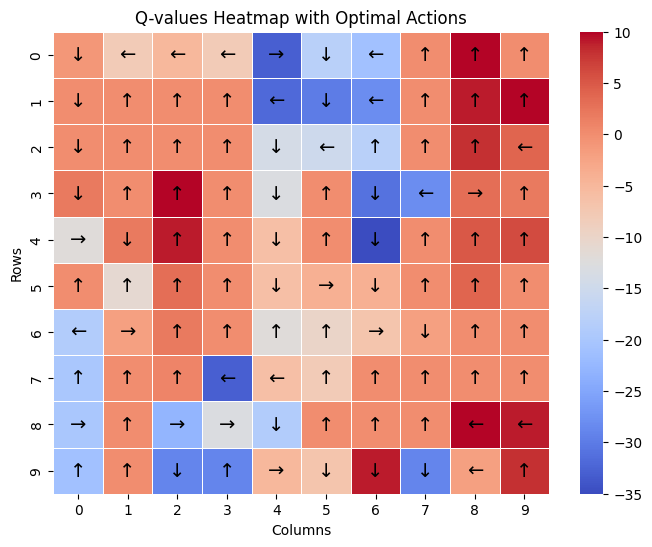

In [ ]:

# Get optimal action for each state (argmax over actions)
optimal_actions = np.argmax(Q, axis=1)

# Compute maximum Q-value per state
max_Q_values = np.max(Q, axis=1)

# Reshape into grid
Q_grid = max_Q_values.reshape((env.num_rows, env.num_cols))
optimal_action_grid = optimal_actions.reshape((env.num_rows, env.num_cols))

plt.figure(figsize=(8, 6))
sns.heatmap(Q_grid, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Maximum Q-values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


# Define action symbols
action_symbols = {0: "↑", 3: "→", 1: "↓", 2: "←"}

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Q_grid, cmap="coolwarm", annot=False, linewidths=0.5)

# Overlay optimal actions
for i in range(env.num_rows):
    for j in range(env.num_cols):
        action = optimal_action_grid[i, j]
        ax.text(j + 0.5, i + 0.5, action_symbols[action], ha="center", va="center", color="black", fontsize=14)

plt.title("Q-values Heatmap with Optimal Actions")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

###  Configuration id 3

#### Configuration Parameters
Learning algorithm = SARSA

Wind = True

Start State = (3,6)

Value of $p$ = 1

Exploration strategy = ϵ -greedy

Train the agent

In [ ]:


env.start_state=np.array([[3,6]])
env.p_good_trans=1
env.wind=True

def parallel_sarsa(env, num_episodes, alpha, gamma, epsilon, num_runs,tuning):
    """Parallel execution of SARSA runs using multiprocessing."""
    with mp.Pool(mp.cpu_count()) as pool:
        results = pool.starmap(sarsa_epsilon, [(env, num_episodes, alpha, gamma, epsilon,tuning)] * num_runs)
    if not tuning:
        return results[0][0],results[0][1],results[0][2],results[0][3]
    else:
        return np.mean(results, axis=0)  # Average across runs


# Hyperparameters
num_runs = 100
coarse_episodes = 170
fine_tune_episodes = 1700
top_k_ratio = 0.1

# Store results from coarse search
top_configs = []

# Coarse Search to filter obviously bad configurations
for alpha in learning_rate:
    for gamma in discount_factor:
        for epsilon in e_greedy:
            reward = parallel_sarsa(env, coarse_episodes, alpha, gamma, epsilon, num_runs,True)
            reward_cumulative = np.sum(reward)
            top_configs.append((reward_cumulative, alpha, gamma, epsilon))

# Sort and keep the top 10%
top_configs = np.array(top_configs)
top_configs = top_configs[top_configs[:, 0].argsort()[::-1]][:int(len(top_configs) * top_k_ratio)]

# Fine-Tuning on Best Configurations
max_reward, max_alpha, max_gamma, max_epsilon = -float('inf'), 0, 0, 0

for reward_cumulative, alpha, gamma, epsilon in top_configs:
    reward = parallel_sarsa(env, fine_tune_episodes, alpha, gamma, epsilon, num_runs,True)
    reward_cumulative = np.sum(reward)

    if reward_cumulative > max_reward:
        max_reward, max_alpha, max_gamma, max_epsilon = reward_cumulative, alpha, gamma, epsilon

print("Best Parameters:", max_alpha, max_gamma, max_epsilon)

num_episodes=10000
Q,reward,steps,state_visits = parallel_sarsa(env, num_episodes, max_alpha, max_gamma,max_epsilon,1,False)  # Train SARSA

Best Parameters: 0.1 0.9 0.001


1. Plot reward curves (during the training phase with the best hyperparameters).

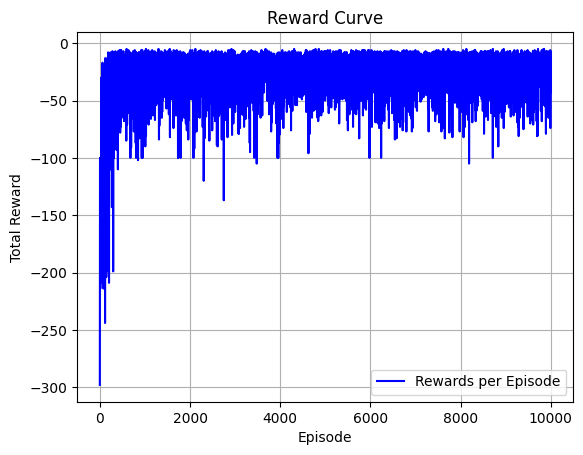

In [ ]:

plt.plot(reward, label="Rewards per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Curve")
plt.legend()
plt.grid()
plt.show()

2. Plot the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).

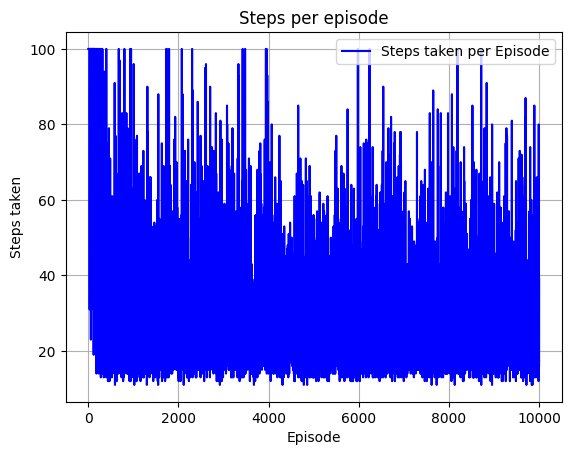

In [ ]:

plt.plot(steps, label="Steps taken per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Steps taken")
plt.title("Steps per episode")
plt.legend()
plt.grid()
plt.show()

3. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.

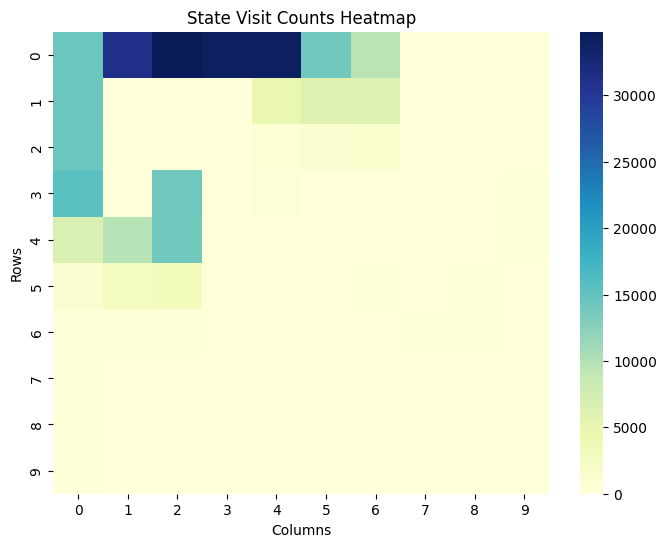

In [ ]:

grid_visits = state_visits.reshape((env.num_rows, env.num_cols))
plt.figure(figsize=(8, 6))
sns.heatmap(grid_visits, cmap="YlGnBu", annot=False, fmt="d")
plt.title("State Visit Counts Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

4. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.

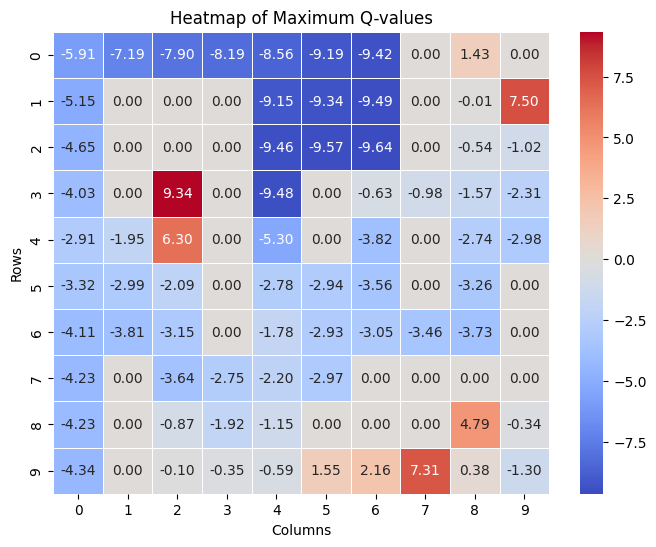

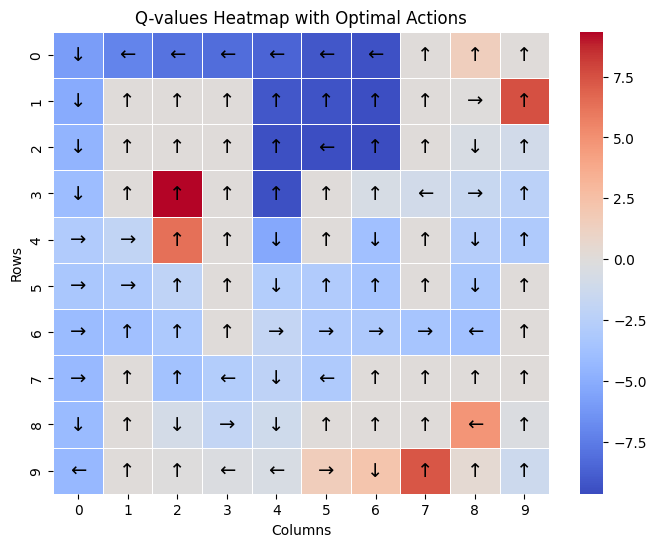

In [ ]:

# Get optimal action for each state (argmax over actions)
optimal_actions = np.argmax(Q, axis=1)

# Compute maximum Q-value per state
max_Q_values = np.max(Q, axis=1)

# Reshape into grid
Q_grid = max_Q_values.reshape((env.num_rows, env.num_cols))
optimal_action_grid = optimal_actions.reshape((env.num_rows, env.num_cols))

plt.figure(figsize=(8, 6))
sns.heatmap(Q_grid, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Maximum Q-values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


# Define action symbols
action_symbols = {0: "↑", 3: "→", 1: "↓", 2: "←"}

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Q_grid, cmap="coolwarm", annot=False, linewidths=0.5)

# Overlay optimal actions
for i in range(env.num_rows):
    for j in range(env.num_cols):
        action = optimal_action_grid[i, j]
        ax.text(j + 0.5, i + 0.5, action_symbols[action], ha="center", va="center", color="black", fontsize=14)

plt.title("Q-values Heatmap with Optimal Actions")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

###  Configuration id 4

#### Configuration Parameters
Learning algorithm = SARSA

Wind = True

Start State = (3,6)

Value of $p$ = 1

Exploration strategy = softmax

Train the agent

In [ ]:


env.start_state=np.array([[3,6]])
env.p_good_trans=1
env.wind=True

def parallel_sarsa(env, num_episodes, alpha, gamma,temp, num_runs,tuning):
    """Parallel execution of SARSA runs using multiprocessing."""
    with mp.Pool(mp.cpu_count()) as pool:
         results = pool.starmap(sarsa_softmax, [(env, num_episodes, alpha, gamma, temp, tuning)] * num_runs)
    if not tuning:
        return results[0][0],results[0][1],results[0][2],results[0][3]
    else:
        return np.mean(results, axis=0)  # Average across runs

# Hyperparameters
num_runs = 100
coarse_episodes = 170
fine_tune_episodes = 1700
top_k_ratio = 0.1

# Store results from coarse search
top_configs = []

# Coarse Search to filter obviously bad configurations
for alpha in learning_rate:
    for gamma in discount_factor:
        for temp in temperature:
            reward = parallel_sarsa(env, coarse_episodes, alpha, gamma,temp, num_runs,True)
            reward_cumulative = np.sum(reward)
            top_configs.append((reward_cumulative, alpha, gamma,temp))

# Sort and keep the top 10%
top_configs = np.array(top_configs)
top_configs = top_configs[top_configs[:, 0].argsort()[::-1]][:int(len(top_configs) * top_k_ratio)]

# Fine-Tuning on Best Configurations
max_reward, max_alpha, max_gamma, max_temp =-float('inf'), 0, 0, 0

for reward_cumulative, alpha, gamma, temp in top_configs:
    reward = parallel_sarsa(env, fine_tune_episodes, alpha, gamma,temp, num_runs,True)
    reward_cumulative = np.sum(reward)

    if reward_cumulative > max_reward:
        max_reward, max_alpha, max_gamma, max_temp = reward_cumulative, alpha, gamma,temp

print("Best Parameters:", max_alpha, max_gamma,max_temp)

num_episodes=10000
Q,reward,steps,state_visits = parallel_sarsa(env, num_episodes, max_alpha, max_gamma,max_temp,1,False)  # Train SARSA

Best Parameters: 1.0 1.0 0.01


1. Plot reward curves (during the training phase with the best hyperparameters).

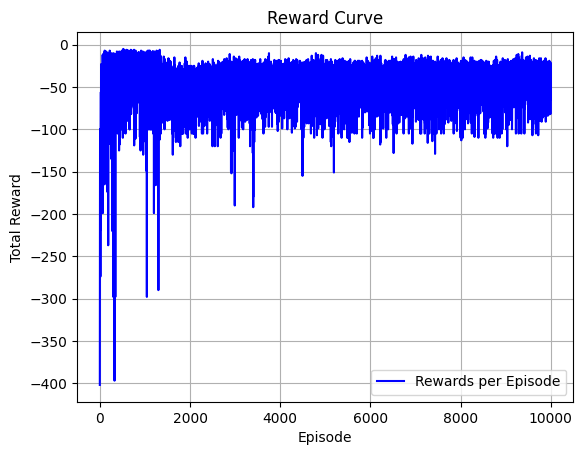

In [ ]:

plt.plot(reward, label="Rewards per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Curve")
plt.legend()
plt.grid()
plt.show()

2. Plot the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).

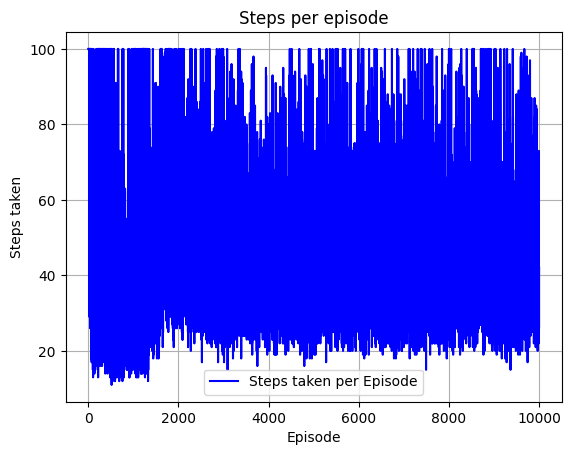

In [ ]:

plt.plot(steps, label="Steps taken per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Steps taken")
plt.title("Steps per episode")
plt.legend()
plt.grid()
plt.show()

3. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.

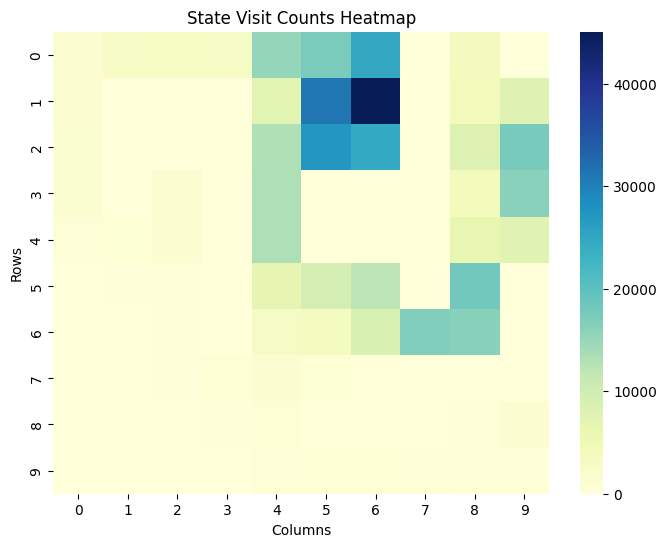

In [ ]:

grid_visits = state_visits.reshape((env.num_rows, env.num_cols))
plt.figure(figsize=(8, 6))
sns.heatmap(grid_visits, cmap="YlGnBu", annot=False, fmt="d")
plt.title("State Visit Counts Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

4. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.

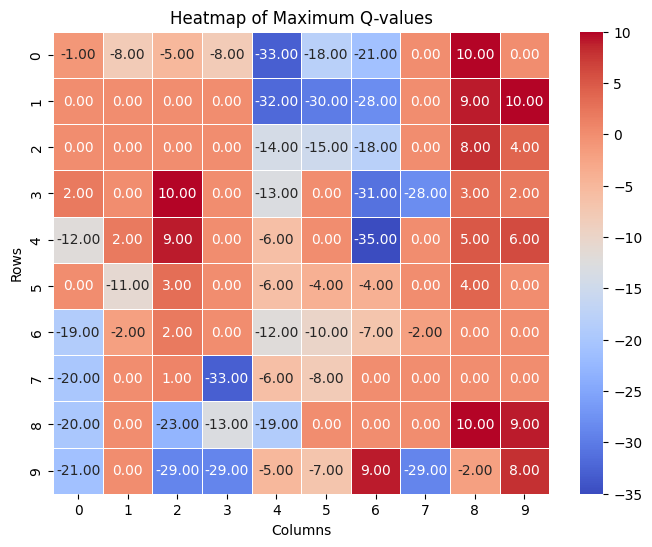

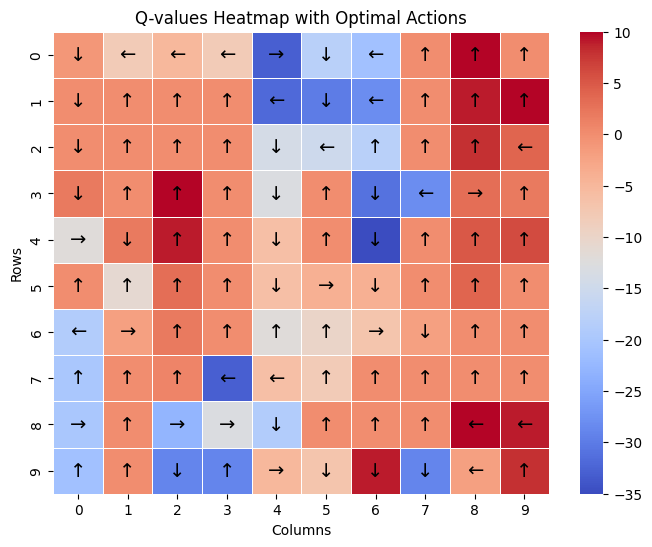

In [ ]:

# Get optimal action for each state (argmax over actions)
optimal_actions = np.argmax(Q, axis=1)

# Compute maximum Q-value per state
max_Q_values = np.max(Q, axis=1)

# Reshape into grid
Q_grid = max_Q_values.reshape((env.num_rows, env.num_cols))
optimal_action_grid = optimal_actions.reshape((env.num_rows, env.num_cols))

plt.figure(figsize=(8, 6))
sns.heatmap(Q_grid, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Maximum Q-values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


# Define action symbols
action_symbols = {0: "↑", 3: "→", 1: "↓", 2: "←"}

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Q_grid, cmap="coolwarm", annot=False, linewidths=0.5)

# Overlay optimal actions
for i in range(env.num_rows):
    for j in range(env.num_cols):
        action = optimal_action_grid[i, j]
        ax.text(j + 0.5, i + 0.5, action_symbols[action], ha="center", va="center", color="black", fontsize=14)

plt.title("Q-values Heatmap with Optimal Actions")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

###  Configuration id 5

#### Configuration Parameters
Learning algorithm = SARSA

Wind = False

Start State = (0,4)

Value of $p$ = 1

Exploration strategy =ϵ -greedy

Train the agent

In [ ]:



env.start_state=np.array([[0,4]])
env.p_good_trans=1
env.wind=False

def parallel_sarsa(env, num_episodes, alpha, gamma, epsilon, num_runs,tuning):
    """Parallel execution of SARSA runs using multiprocessing."""
    with mp.Pool(mp.cpu_count()) as pool:
        results = pool.starmap(sarsa_epsilon, [(env, num_episodes, alpha, gamma, epsilon, tuning)] * num_runs)
    if not tuning:
        return results[0][0],results[0][1],results[0][2],results[0][3]
    else:
        return np.mean(results, axis=0)  # Average across runs

# Hyperparameters
num_runs = 100
coarse_episodes = 170
fine_tune_episodes = 1700
top_k_ratio = 0.1

# Store results from coarse search
top_configs = []

# Coarse Search to filter obviously bad configurations
for alpha in learning_rate:
    for gamma in discount_factor:
        for epsilon in e_greedy:
            reward = parallel_sarsa(env, coarse_episodes, alpha, gamma, epsilon, num_runs,True)
            reward_cumulative = np.sum(reward)
            top_configs.append((reward_cumulative, alpha, gamma, epsilon))

# Sort and keep the top 10%
top_configs = np.array(top_configs)
top_configs = top_configs[top_configs[:, 0].argsort()[::-1]][:int(len(top_configs) * top_k_ratio)]

# Fine-Tuning on Best Configurations
max_reward, max_alpha, max_gamma, max_epsilon = -float('inf'), 0, 0, 0

for reward_cumulative, alpha, gamma, epsilon in top_configs:
    reward = parallel_sarsa(env, fine_tune_episodes, alpha, gamma, epsilon, num_runs,True)
    reward_cumulative = np.sum(reward)

    if reward_cumulative > max_reward:
        max_reward, max_alpha, max_gamma, max_epsilon = reward_cumulative, alpha, gamma, epsilon

print("Best Parameters:", max_alpha, max_gamma, max_epsilon)

num_episodes=10000
Q,reward,steps,state_visits = parallel_sarsa(env, num_episodes, max_alpha, max_gamma,max_epsilon,1,False)  # Train SARSA

Best Parameters: 0.1 1.0 0.01


1. Plot reward curves (during the training phase with the best hyperparameters).

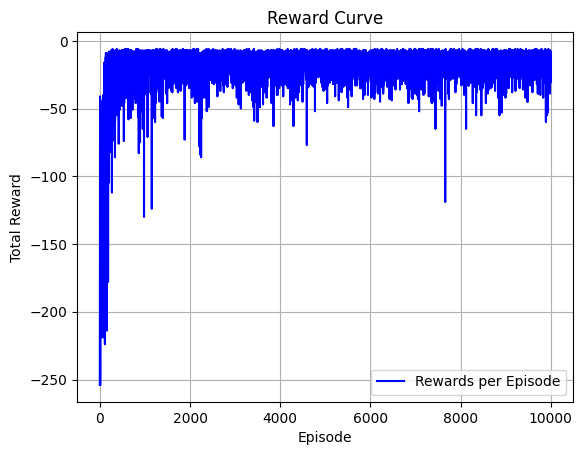

In [ ]:

plt.plot(reward, label="Rewards per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Curve")
plt.legend()
plt.grid()
plt.show()

2. Plot the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).

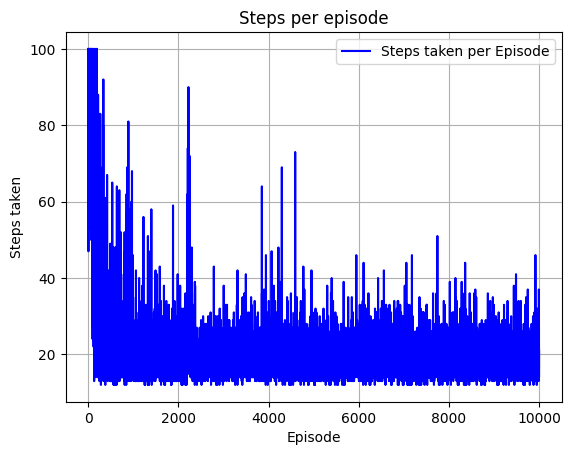

In [ ]:

plt.plot(steps, label="Steps taken per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Steps taken")
plt.title("Steps per episode")
plt.legend()
plt.grid()
plt.show()

3. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.

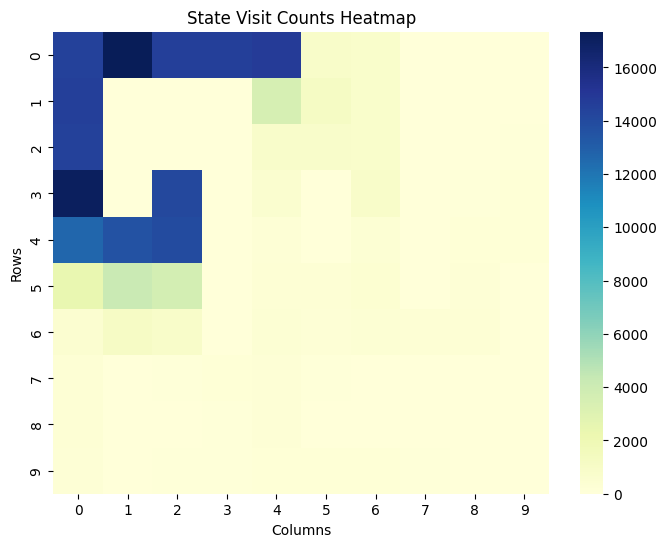

In [ ]:

grid_visits = state_visits.reshape((env.num_rows, env.num_cols))
plt.figure(figsize=(8, 6))
sns.heatmap(grid_visits, cmap="YlGnBu", annot=False, fmt="d")
plt.title("State Visit Counts Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

4. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.

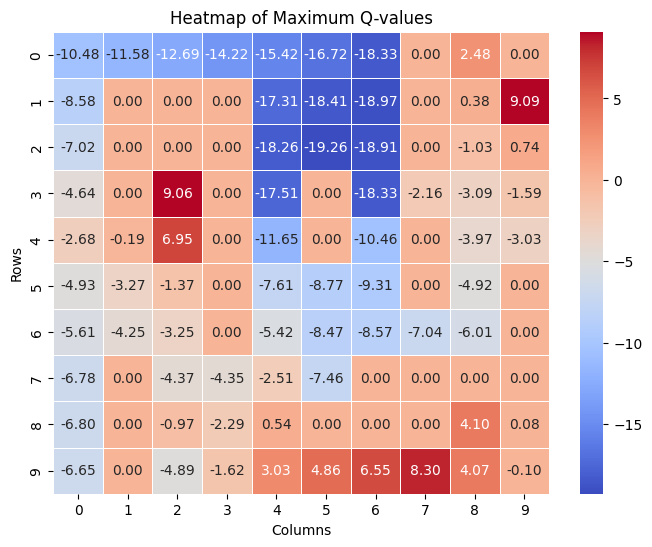

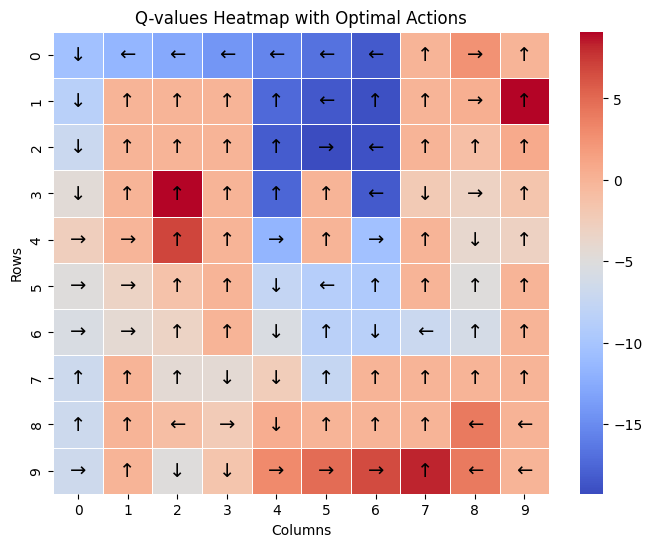

In [ ]:

# Get optimal action for each state (argmax over actions)
optimal_actions = np.argmax(Q, axis=1)

# Compute maximum Q-value per state
max_Q_values = np.max(Q, axis=1)

# Reshape into grid
Q_grid = max_Q_values.reshape((env.num_rows, env.num_cols))
optimal_action_grid = optimal_actions.reshape((env.num_rows, env.num_cols))

plt.figure(figsize=(8, 6))
sns.heatmap(Q_grid, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Maximum Q-values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


# Define action symbols
action_symbols = {0: "↑", 3: "→", 1: "↓", 2: "←"}

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Q_grid, cmap="coolwarm", annot=False, linewidths=0.5)

# Overlay optimal actions
for i in range(env.num_rows):
    for j in range(env.num_cols):
        action = optimal_action_grid[i, j]
        ax.text(j + 0.5, i + 0.5, action_symbols[action], ha="center", va="center", color="black", fontsize=14)

plt.title("Q-values Heatmap with Optimal Actions")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

###  Configuration id 6

#### Configuration Parameters
Learning algorithm = SARSA

Wind = False

Start State = (0,4)

Value of $p$ = 1

Exploration strategy = softmax

Train the agent

In [ ]:


env.start_state=np.array([[0,4]])
env.p_good_trans=1
env.wind=False

def parallel_sarsa(env, num_episodes, alpha, gamma,temp, num_runs,tuning):
    """Parallel execution of SARSA runs using multiprocessing."""
    with mp.Pool(mp.cpu_count()) as pool:
         results = pool.starmap(sarsa_softmax, [(env, num_episodes, alpha, gamma, temp, tuning)] * num_runs)
    if not tuning:
        return results[0][0],results[0][1],results[0][2],results[0][3]
    else:
        return np.mean(results, axis=0)  # Average across runs
# Hyperparameters
num_runs = 100
coarse_episodes = 170
fine_tune_episodes = 1700
top_k_ratio = 0.1

# Store results from coarse search
top_configs = []

# Coarse Search to filter obviously bad configurations
for alpha in learning_rate:
    for gamma in discount_factor:
        for temp in temperature:
            reward = parallel_sarsa(env, coarse_episodes, alpha, gamma,temp, num_runs,True)
            reward_cumulative = np.sum(reward)
            top_configs.append((reward_cumulative, alpha, gamma,temp))

# Sort and keep the top 10%
top_configs = np.array(top_configs)
top_configs = top_configs[top_configs[:, 0].argsort()[::-1]][:int(len(top_configs) * top_k_ratio)]

# Fine-Tuning on Best Configurations
max_reward, max_alpha, max_gamma, max_temp = -float('inf'), 0, 0, 0

for reward_cumulative, alpha, gamma, temp in top_configs:
    reward = parallel_sarsa(env, fine_tune_episodes, alpha, gamma, temp, num_runs,True)
    reward_cumulative = np.sum(reward)

    if reward_cumulative > max_reward:
        max_reward, max_alpha, max_gamma, max_temp = reward_cumulative, alpha, gamma,temp

print("Best Parameters:", max_alpha, max_gamma,max_temp)

num_episodes=10000
Q,reward,steps,state_visits = parallel_sarsa(env, num_episodes, max_alpha, max_gamma,max_temp,1,False)  # Train SARSA

Best Parameters: 1.0 1.0 0.1


1. Plot reward curves (during the training phase with the best hyperparameters).

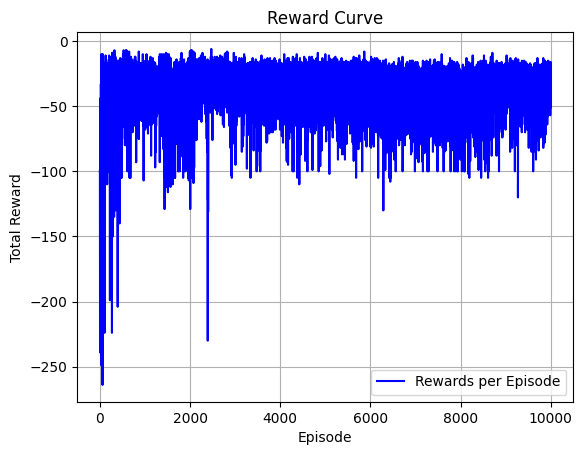

In [ ]:

plt.plot(reward, label="Rewards per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Curve")
plt.legend()
plt.grid()
plt.show()

2. Plot the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).

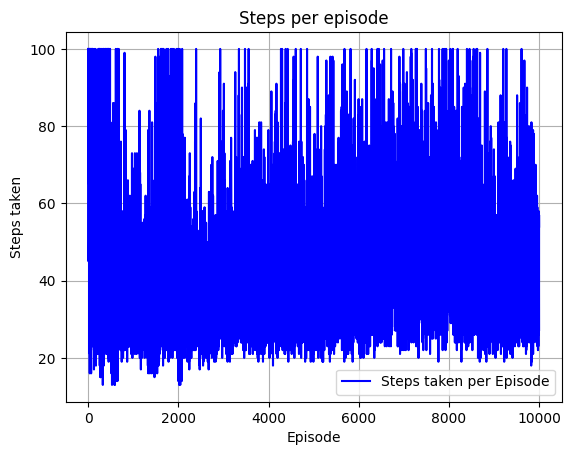

In [ ]:

plt.plot(steps, label="Steps taken per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Steps taken")
plt.title("Steps per episode")
plt.legend()
plt.grid()
plt.show()

3. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.

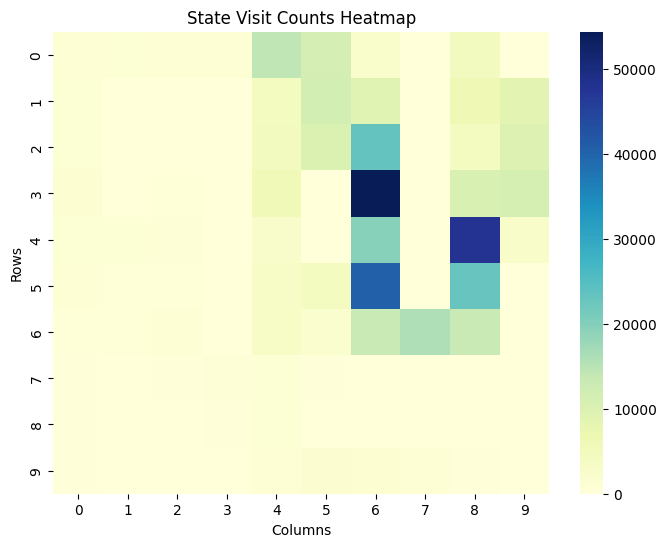

In [ ]:

grid_visits = state_visits.reshape((env.num_rows, env.num_cols))
plt.figure(figsize=(8, 6))
sns.heatmap(grid_visits, cmap="YlGnBu", annot=False, fmt="d")
plt.title("State Visit Counts Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

4. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.

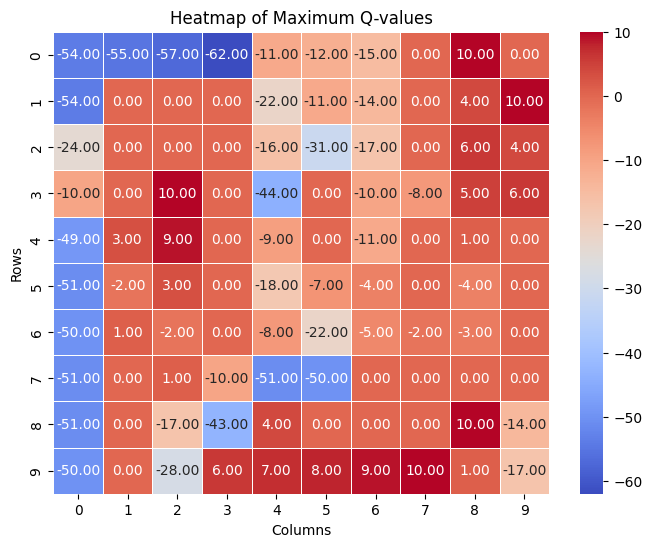

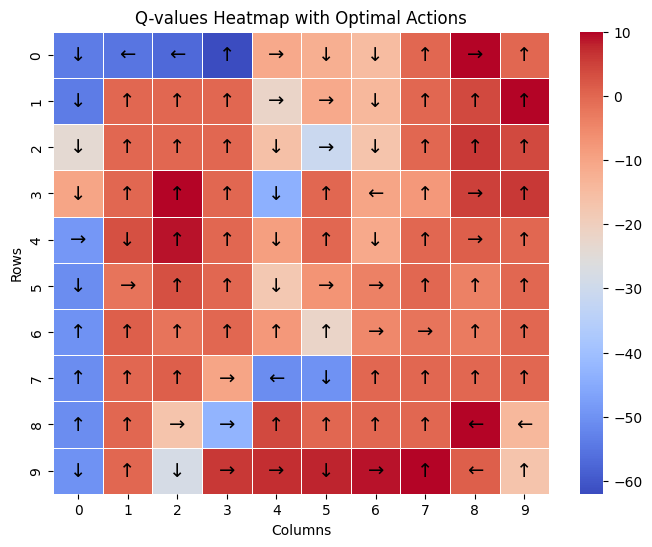

In [ ]:

# Get optimal action for each state (argmax over actions)
optimal_actions = np.argmax(Q, axis=1)

# Compute maximum Q-value per state
max_Q_values = np.max(Q, axis=1)

# Reshape into grid
Q_grid = max_Q_values.reshape((env.num_rows, env.num_cols))
optimal_action_grid = optimal_actions.reshape((env.num_rows, env.num_cols))

plt.figure(figsize=(8, 6))
sns.heatmap(Q_grid, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Maximum Q-values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


# Define action symbols
action_symbols = {0: "↑", 3: "→", 1: "↓", 2: "←"}

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Q_grid, cmap="coolwarm", annot=False, linewidths=0.5)

# Overlay optimal actions
for i in range(env.num_rows):
    for j in range(env.num_cols):
        action = optimal_action_grid[i, j]
        ax.text(j + 0.5, i + 0.5, action_symbols[action], ha="center", va="center", color="black", fontsize=14)

plt.title("Q-values Heatmap with Optimal Actions")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

###  Configuration id 7

#### Configuration Parameters
Learning algorithm = SARSA

Wind = False

Start State = (3,6)

Value of $p$ = 1

Exploration strategy = ϵ -greedy

Train the agent

In [ ]:


env.start_state=np.array([[3,6]])
env.p_good_trans=1
env.wind=False

def parallel_sarsa(env, num_episodes, alpha, gamma, epsilon, num_runs,tuning):
    """Parallel execution of SARSA runs using multiprocessing."""
    with mp.Pool(mp.cpu_count()) as pool:
        results = pool.starmap(sarsa_epsilon, [(env, num_episodes, alpha, gamma, epsilon, tuning)] * num_runs)
    if not tuning:
        return results[0][0],results[0][1],results[0][2],results[0][3]
    else:
        return np.mean(results, axis=0)  # Average across runs


# Hyperparameters
num_runs = 100
coarse_episodes = 170
fine_tune_episodes = 1700
top_k_ratio = 0.1

# Store results from coarse search
top_configs = []

# Coarse Search to filter obviously bad configurations
for alpha in learning_rate:
    for gamma in discount_factor:
        for epsilon in e_greedy:
            reward = parallel_sarsa(env, coarse_episodes, alpha, gamma, epsilon, num_runs,True)
            reward_cumulative = np.sum(reward)
            top_configs.append((reward_cumulative, alpha, gamma, epsilon))

# Sort and keep the top 10%
top_configs = np.array(top_configs)
top_configs = top_configs[top_configs[:, 0].argsort()[::-1]][:int(len(top_configs) * top_k_ratio)]

# Fine-Tuning on Best Configurations
max_reward, max_alpha, max_gamma, max_epsilon = -float('inf'), 0, 0, 0

for reward_cumulative, alpha, gamma, epsilon in top_configs:
    reward = parallel_sarsa(env, fine_tune_episodes, alpha, gamma, epsilon, num_runs,True)
    reward_cumulative = np.sum(reward)

    if reward_cumulative > max_reward:
        max_reward, max_alpha, max_gamma, max_epsilon = reward_cumulative, alpha, gamma, epsilon

print("Best Parameters:", max_alpha, max_gamma, max_epsilon)

num_episodes=10000
Q,reward,steps,state_visits = parallel_sarsa(env, num_episodes, max_alpha, max_gamma,max_epsilon,1,False)  # Train SARSA

Best Parameters: 0.1 1.0 0.01


1. Plot reward curves (during the training phase with the best hyperparameters).

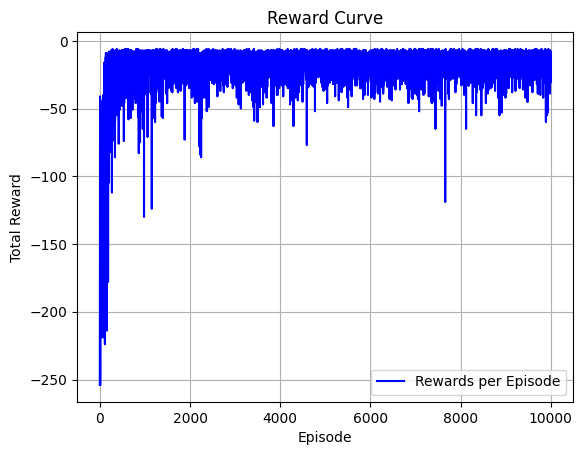

In [ ]:

plt.plot(reward, label="Rewards per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Curve")
plt.legend()
plt.grid()
plt.show()

2. Plot the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).

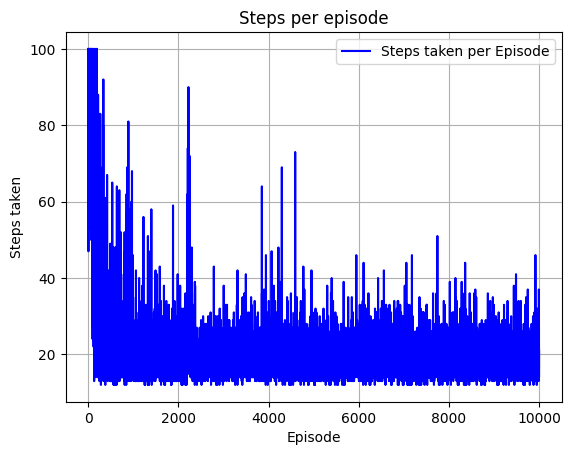

In [ ]:

plt.plot(steps, label="Steps taken per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Steps taken")
plt.title("Steps per episode")
plt.legend()
plt.grid()
plt.show()

3. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.

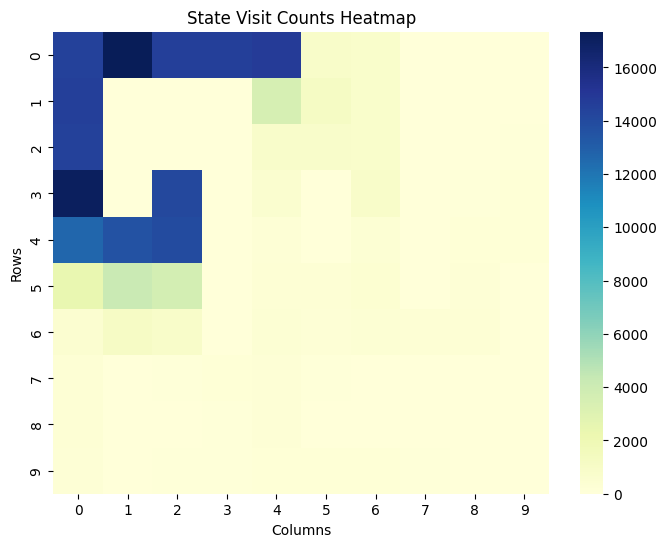

In [ ]:

grid_visits = state_visits.reshape((env.num_rows, env.num_cols))
plt.figure(figsize=(8, 6))
sns.heatmap(grid_visits, cmap="YlGnBu", annot=False, fmt="d")
plt.title("State Visit Counts Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

4. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.

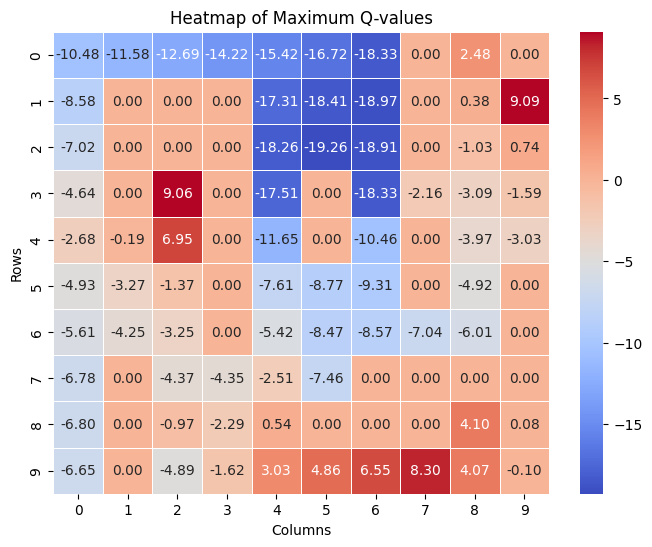

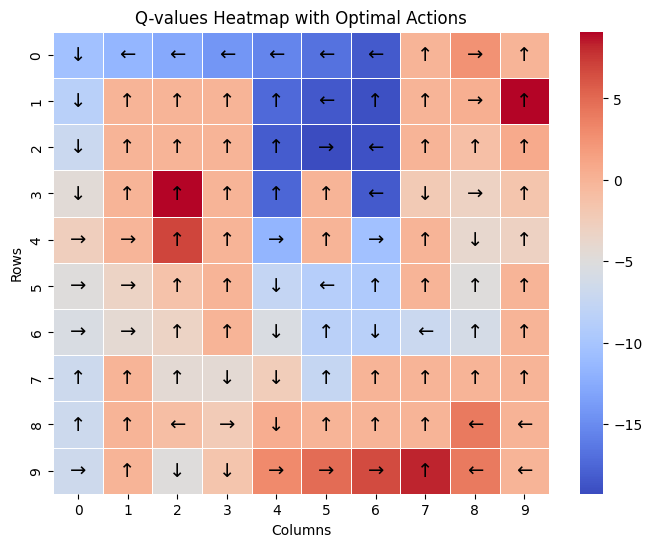

In [ ]:

# Get optimal action for each state (argmax over actions)
optimal_actions = np.argmax(Q, axis=1)

# Compute maximum Q-value per state
max_Q_values = np.max(Q, axis=1)

# Reshape into grid
Q_grid = max_Q_values.reshape((env.num_rows, env.num_cols))
optimal_action_grid = optimal_actions.reshape((env.num_rows, env.num_cols))

plt.figure(figsize=(8, 6))
sns.heatmap(Q_grid, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Maximum Q-values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


# Define action symbols
action_symbols = {0: "↑", 3: "→", 1: "↓", 2: "←"}

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Q_grid, cmap="coolwarm", annot=False, linewidths=0.5)

# Overlay optimal actions
for i in range(env.num_rows):
    for j in range(env.num_cols):
        action = optimal_action_grid[i, j]
        ax.text(j + 0.5, i + 0.5, action_symbols[action], ha="center", va="center", color="black", fontsize=14)

plt.title("Q-values Heatmap with Optimal Actions")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

###  Configuration id 8

#### Configuration Parameters
Learning algorithm = SARSA

Wind = False

Start State = (3,6)

Value of $p$ = 1

Exploration strategy = softmax

Train the agent

In [ ]:


env.start_state=np.array([[3,6]])
env.p_good_trans=1
env.wind=False

def parallel_sarsa(env, num_episodes, alpha, gamma,temp, num_runs,tuning):
    """Parallel execution of SARSA runs using multiprocessing."""
    with mp.Pool(mp.cpu_count()) as pool:
         results = pool.starmap(sarsa_softmax, [(env, num_episodes, alpha, gamma, temp, tuning)] * num_runs)
    if not tuning:
        return results[0][0],results[0][1],results[0][2],results[0][3]
    else:
        return np.mean(results, axis=0)  # Average across runs
# Hyperparameters
num_runs = 100
coarse_episodes = 170
fine_tune_episodes = 1700
top_k_ratio = 0.1

# Store results from coarse search
top_configs = []

# Coarse Search to filter obviously bad configurations
for alpha in learning_rate:
    for gamma in discount_factor:
        for temp in temperature:
            reward = parallel_sarsa(env, coarse_episodes, alpha, gamma,temp, num_runs,True)
            reward_cumulative = np.sum(reward)
            top_configs.append((reward_cumulative, alpha, gamma,temp))

# Sort and keep the top 10%
top_configs = np.array(top_configs)
top_configs = top_configs[top_configs[:, 0].argsort()[::-1]][:int(len(top_configs) * top_k_ratio)]

# Fine-Tuning on Best Configurations
max_reward, max_alpha, max_gamma, max_temp = -float('inf'), 0, 0, 0

for reward_cumulative, alpha, gamma, temp in top_configs:
    reward = parallel_sarsa(env, fine_tune_episodes, alpha, gamma, temp, num_runs,True)
    reward_cumulative = np.sum(reward)

    if reward_cumulative > max_reward:
        max_reward, max_alpha, max_gamma, max_temp = reward_cumulative, alpha, gamma,temp

print("Best Parameters:", max_alpha, max_gamma,max_temp)

num_episodes=10000
Q,reward,steps,state_visits = parallel_sarsa(env, num_episodes, max_alpha, max_gamma,max_temp,1,False)  # Train SARSA

Best Parameters: 1.0 1.0 0.1


1. Plot reward curves (during the training phase with the best hyperparameters).

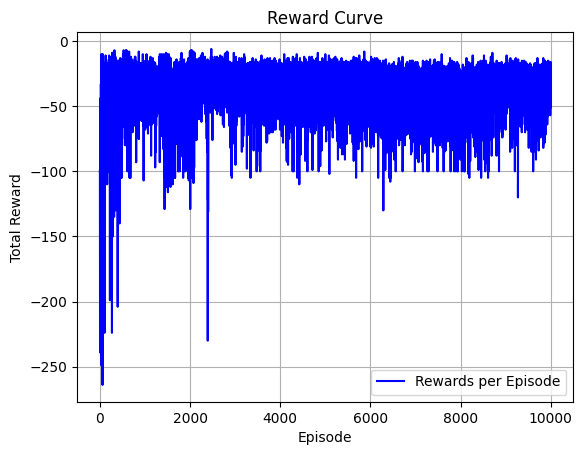

In [ ]:

plt.plot(reward, label="Rewards per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Curve")
plt.legend()
plt.grid()
plt.show()

2. Plot the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).

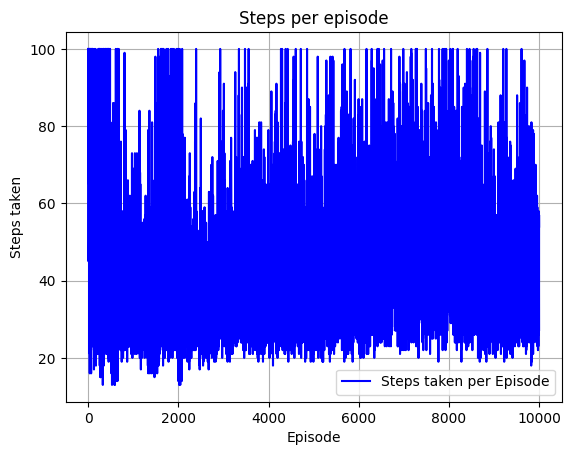

In [ ]:

plt.plot(steps, label="Steps taken per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Steps taken")
plt.title("Steps per episode")
plt.legend()
plt.grid()
plt.show()

3. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.

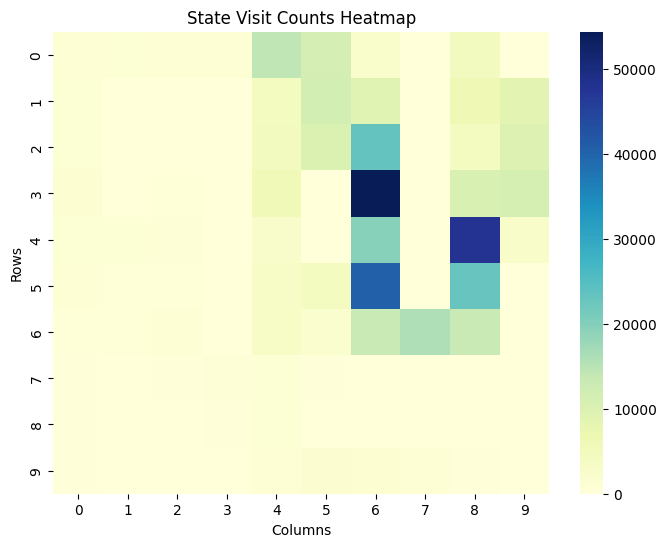

In [ ]:

grid_visits = state_visits.reshape((env.num_rows, env.num_cols))
plt.figure(figsize=(8, 6))
sns.heatmap(grid_visits, cmap="YlGnBu", annot=False, fmt="d")
plt.title("State Visit Counts Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

4. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.

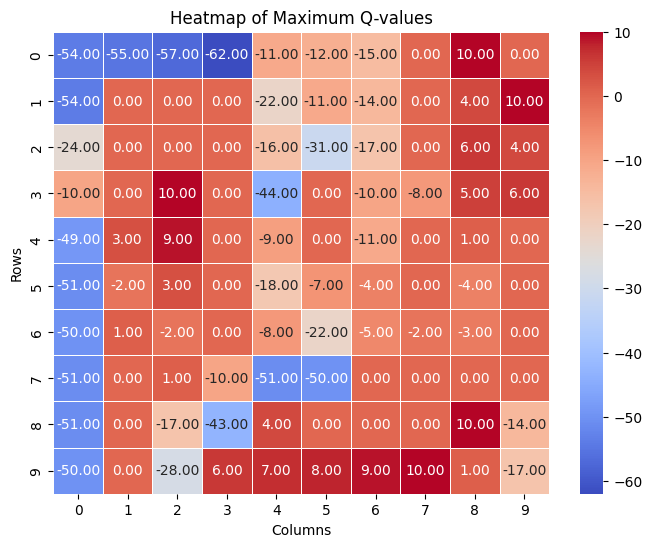

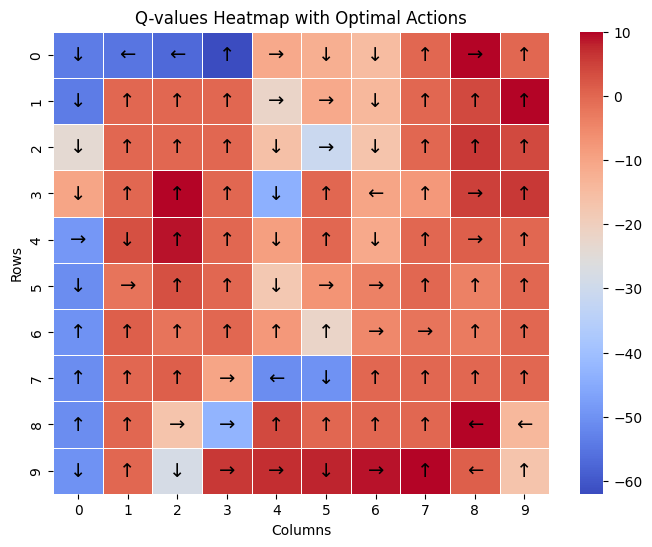

In [ ]:

# Get optimal action for each state (argmax over actions)
optimal_actions = np.argmax(Q, axis=1)

# Compute maximum Q-value per state
max_Q_values = np.max(Q, axis=1)

# Reshape into grid
Q_grid = max_Q_values.reshape((env.num_rows, env.num_cols))
optimal_action_grid = optimal_actions.reshape((env.num_rows, env.num_cols))

plt.figure(figsize=(8, 6))
sns.heatmap(Q_grid, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Maximum Q-values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


# Define action symbols
action_symbols = {0: "↑", 3: "→", 1: "↓", 2: "←"}

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Q_grid, cmap="coolwarm", annot=False, linewidths=0.5)

# Overlay optimal actions
for i in range(env.num_rows):
    for j in range(env.num_cols):
        action = optimal_action_grid[i, j]
        ax.text(j + 0.5, i + 0.5, action_symbols[action], ha="center", va="center", color="black", fontsize=14)

plt.title("Q-values Heatmap with Optimal Actions")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

###  Configuration id 9

#### Configuration Parameters
Learning algorithm = Q-Learning

Wind = False

Start State = (0,4)

Value of $p$ = 1

Exploration strategy = ϵ -greedy

Train the agent

In [ ]:


env.start_state=np.array([[0,4]])
env.p_good_trans=1
env.wind=False

def parallel_Qlearning(env, num_episodes, alpha, gamma, epsilon, num_runs,tuning):
    """Parallel execution of Q-Learning runs using multiprocessing."""
    with mp.Pool(mp.cpu_count()) as pool:
        results = pool.starmap(q_learning_epsilon, [(env, num_episodes, alpha, gamma, epsilon, tuning)] * num_runs)
    if not tuning:
        return results[0][0],results[0][1],results[0][2],results[0][3]
    else:
        return np.mean(results, axis=0)  # Average across runs


# Hyperparameters
num_runs = 100
coarse_episodes = 170
fine_tune_episodes = 1700
top_k_ratio = 0.1

# Store results from coarse search
top_configs = []

# Coarse Search to filter obviously bad configurations
for alpha in learning_rate:
    for gamma in discount_factor:
        for epsilon in e_greedy:
            reward = parallel_Qlearning(env, coarse_episodes, alpha, gamma, epsilon, num_runs,True)
            reward_cumulative = np.sum(reward)
            top_configs.append((reward_cumulative, alpha, gamma, epsilon))

# Sort and keep the top 10%
top_configs = np.array(top_configs)
top_configs = top_configs[top_configs[:, 0].argsort()[::-1]][:int(len(top_configs) * top_k_ratio)]

# Fine-Tuning on Best Configurations
max_reward, max_alpha, max_gamma, max_epsilon = -float('inf'), 0, 0, 0

for reward_cumulative, alpha, gamma, epsilon in top_configs:
    reward = parallel_Qlearning(env, coarse_episodes, alpha, gamma, epsilon, num_runs,True)
    reward_cumulative = np.sum(reward)

    if reward_cumulative > max_reward:
        max_reward, max_alpha, max_gamma, max_epsilon = reward_cumulative, alpha, gamma, epsilon

print("Best Parameters:", max_alpha, max_gamma, max_epsilon)

num_episodes=10000
Q,reward,steps,state_visits = parallel_Qlearning(env, num_episodes, max_alpha, max_gamma,max_epsilon,1,False)  # Train QLearning


Best Parameters: 1.0 1.0 0.001


1. Plot reward curves (during the training phase with the best hyperparameters).

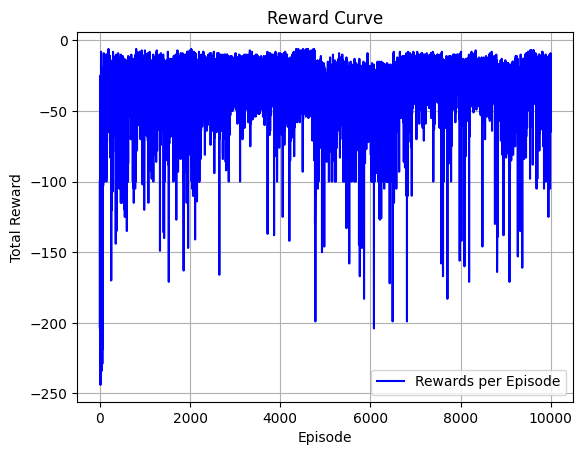

In [ ]:

plt.plot(reward, label="Rewards per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Curve")
plt.legend()
plt.grid()
plt.show()

2. Plot the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).

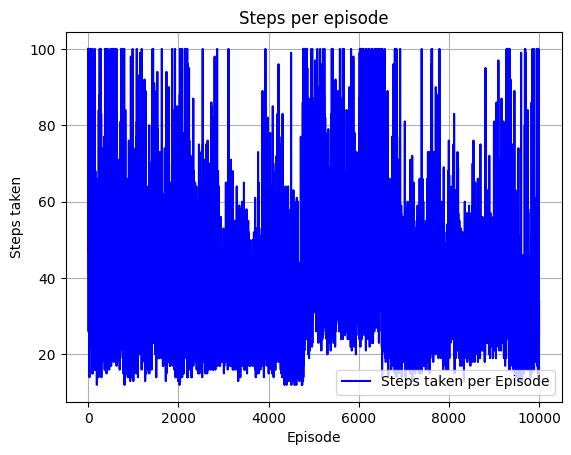

In [ ]:

plt.plot(steps, label="Steps taken per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Steps taken")
plt.title("Steps per episode")
plt.legend()
plt.grid()
plt.show()

3. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.

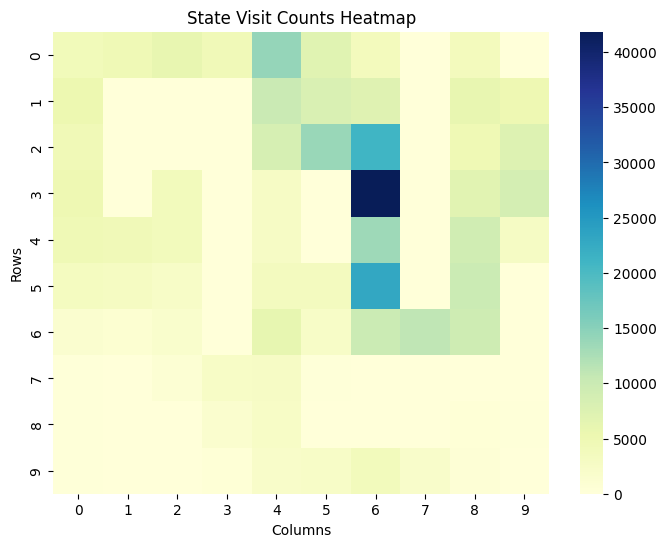

In [ ]:

grid_visits = state_visits.reshape((env.num_rows, env.num_cols))
plt.figure(figsize=(8, 6))
sns.heatmap(grid_visits, cmap="YlGnBu", annot=False, fmt="d")
plt.title("State Visit Counts Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

4. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.

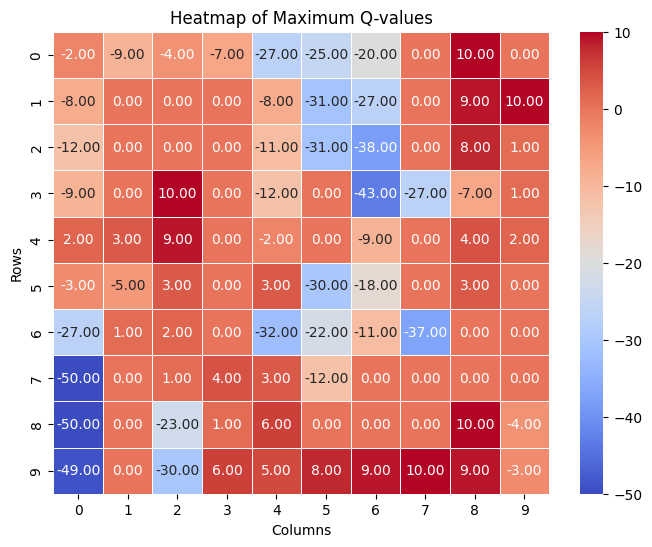

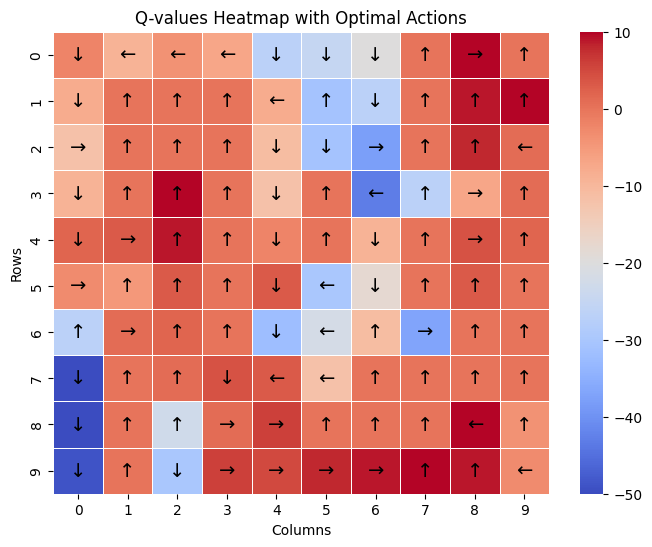

In [ ]:

# Get optimal action for each state (argmax over actions)
optimal_actions = np.argmax(Q, axis=1)

# Compute maximum Q-value per state
max_Q_values = np.max(Q, axis=1)

# Reshape into grid
Q_grid = max_Q_values.reshape((env.num_rows, env.num_cols))
optimal_action_grid = optimal_actions.reshape((env.num_rows, env.num_cols))

plt.figure(figsize=(8, 6))
sns.heatmap(Q_grid, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Maximum Q-values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


# Define action symbols
action_symbols = {0: "↑", 3: "→", 1: "↓", 2: "←"}

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Q_grid, cmap="coolwarm", annot=False, linewidths=0.5)

# Overlay optimal actions
for i in range(env.num_rows):
    for j in range(env.num_cols):
        action = optimal_action_grid[i, j]
        ax.text(j + 0.5, i + 0.5, action_symbols[action], ha="center", va="center", color="black", fontsize=14)

plt.title("Q-values Heatmap with Optimal Actions")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

###  Configuration id 10

#### Configuration Parameters
Learning algorithm = Q-Learning

Wind = False

Start State = (0,4)

Value of $p$ = 1

Exploration strategy = softmax

Train the agent

In [ ]:


env.start_state=np.array([[0,4]])
env.p_good_trans=1
env.wind=False

def parallel_Qlearning(env, num_episodes, alpha, gamma, temp, num_runs,tuning):
    """Parallel execution of Q-Learning runs using multiprocessing."""
    with mp.Pool(mp.cpu_count()) as pool:
        results = pool.starmap(q_learning_softmax, [(env, num_episodes, alpha, gamma, temp, tuning)] * num_runs)
    if not tuning:
        return results[0][0],results[0][1],results[0][2],results[0][3]
    else:
        return np.mean(results, axis=0)  # Average across runs


# Hyperparameters
num_runs = 100
coarse_episodes = 170
fine_tune_episodes = 1700
top_k_ratio = 0.1

# Store results from coarse search
top_configs = []

# Coarse Search to filter obviously bad configurations
for alpha in learning_rate:
    for gamma in discount_factor:
        for temp in temperature:
            reward = parallel_Qlearning(env, coarse_episodes, alpha, gamma, temp, num_runs,True)
            reward_cumulative = np.sum(reward)
            top_configs.append((reward_cumulative, alpha, gamma, temp))

# Sort and keep the top 10%
top_configs = np.array(top_configs)
top_configs = top_configs[top_configs[:, 0].argsort()[::-1]][:int(len(top_configs) * top_k_ratio)]

# Fine-Tuning on Best Configurations
max_reward, max_alpha, max_gamma, max_temp =-float('inf'), 0, 0, 0

for reward_cumulative, alpha, gamma, temp in top_configs:
    reward = parallel_Qlearning(env, coarse_episodes, alpha, gamma, temp, num_runs,True)
    reward_cumulative = np.sum(reward)

    if reward_cumulative > max_reward:
        max_reward, max_alpha, max_gamma, max_temp = reward_cumulative, alpha, gamma,temp

print("Best Parameters:", max_alpha, max_gamma, max_temp)

num_episodes=10000
Q,reward,steps,state_visits = parallel_Qlearning(env, num_episodes, max_alpha, max_gamma,max_temp,1,False)  # Train QLearning


Best Parameters: 1.0 1.0 0.01


1. Plot reward curves (during the training phase with the best hyperparameters).

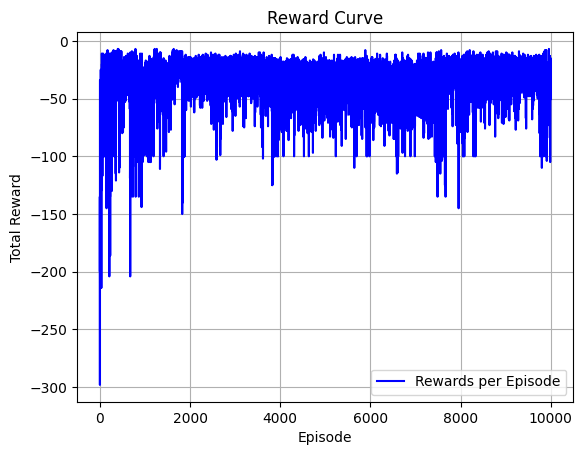

In [ ]:

plt.plot(reward, label="Rewards per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Curve")
plt.legend()
plt.grid()
plt.show()

2. Plot the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).

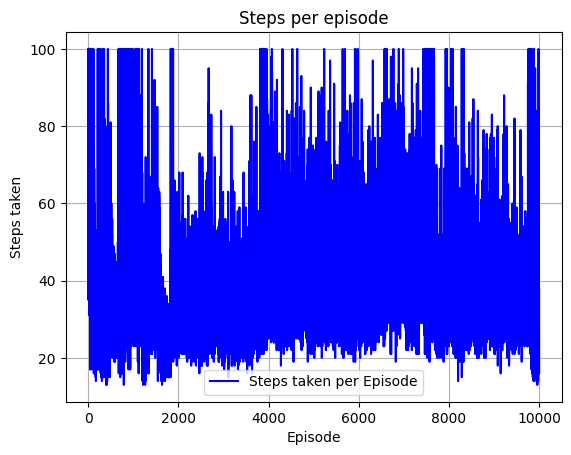

In [ ]:

plt.plot(steps, label="Steps taken per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Steps taken")
plt.title("Steps per episode")
plt.legend()
plt.grid()
plt.show()

3. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.

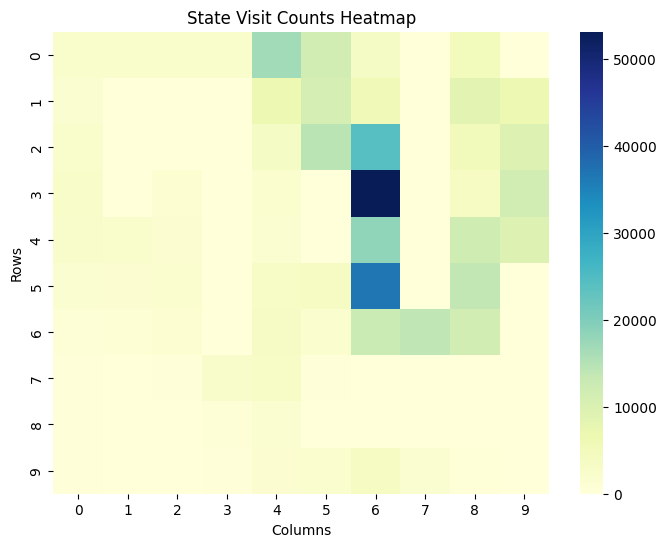

In [ ]:

grid_visits = state_visits.reshape((env.num_rows, env.num_cols))
plt.figure(figsize=(8, 6))
sns.heatmap(grid_visits, cmap="YlGnBu", annot=False, fmt="d")
plt.title("State Visit Counts Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

4. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.

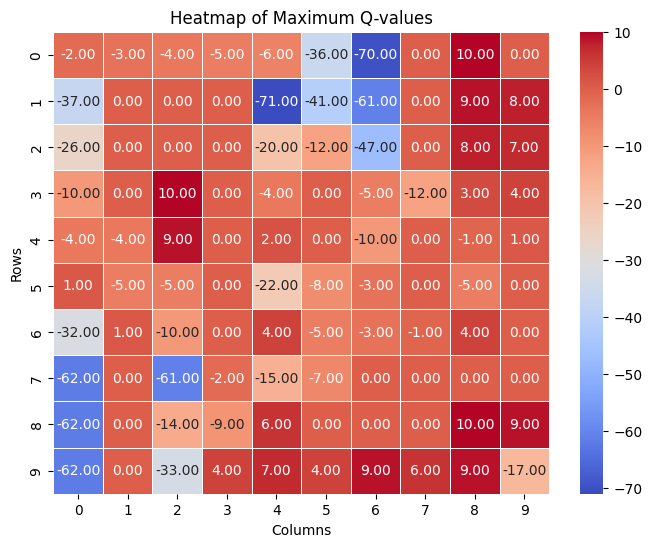

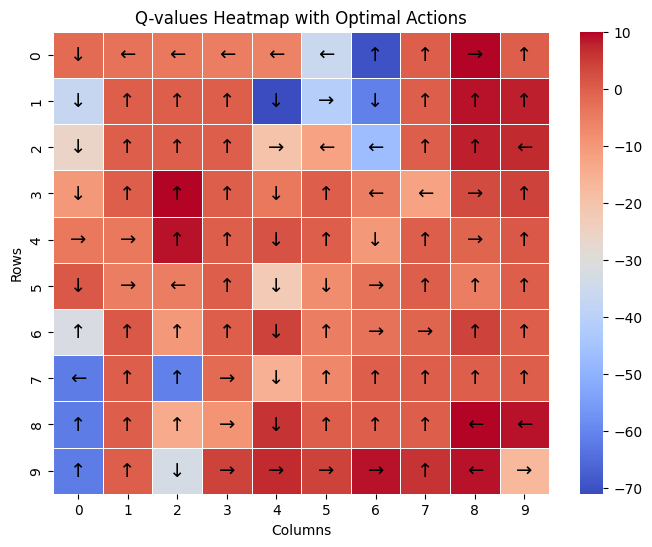

In [ ]:

# Get optimal action for each state (argmax over actions)
optimal_actions = np.argmax(Q, axis=1)

# Compute maximum Q-value per state
max_Q_values = np.max(Q, axis=1)

# Reshape into grid
Q_grid = max_Q_values.reshape((env.num_rows, env.num_cols))
optimal_action_grid = optimal_actions.reshape((env.num_rows, env.num_cols))

plt.figure(figsize=(8, 6))
sns.heatmap(Q_grid, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Maximum Q-values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


# Define action symbols
action_symbols = {0: "↑", 3: "→", 1: "↓", 2: "←"}

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Q_grid, cmap="coolwarm", annot=False, linewidths=0.5)

# Overlay optimal action
for i in range(env.num_rows):
    for j in range(env.num_cols):
        action = optimal_action_grid[i, j]
        ax.text(j + 0.5, i + 0.5, action_symbols[action], ha="center", va="center", color="black", fontsize=14)

plt.title("Q-values Heatmap with Optimal Actions")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

###  Configuration id 11

#### Configuration Parameters
Learning algorithm = Q-Learning

Wind = False

Start State = (0,4)

Value of $p$ = 0.7

Exploration strategy = ϵ -greedy

Train the agent

In [ ]:


env.start_state=np.array([[0,4]])
env.p_good_trans=0.7
env.wind=False

def parallel_Qlearning(env, num_episodes, alpha, gamma, epsilon, num_runs,tuning):
    """Parallel execution of Q-Learning runs using multiprocessing."""
    with mp.Pool(mp.cpu_count()) as pool:
        results = pool.starmap(q_learning_epsilon, [(env, num_episodes, alpha, gamma, epsilon, tuning)] * num_runs)
    if not tuning:
        return results[0][0],results[0][1],results[0][2],results[0][3]
    else:
        return np.mean(results, axis=0)  # Average across runs


# Hyperparameters
num_runs = 100
coarse_episodes = 170
fine_tune_episodes = 1700
top_k_ratio = 0.1

# Store results from coarse search
top_configs = []

# Coarse Search to filter obviously bad configurations
for alpha in learning_rate:
    for gamma in discount_factor:
        for epsilon in e_greedy:
            reward = parallel_Qlearning(env, coarse_episodes, alpha, gamma, epsilon, num_runs,True)
            reward_cumulative = np.sum(reward)
            top_configs.append((reward_cumulative, alpha, gamma, epsilon))

# Sort and keep the top 10%
top_configs = np.array(top_configs)
top_configs = top_configs[top_configs[:, 0].argsort()[::-1]][:int(len(top_configs) * top_k_ratio)]

# Fine-Tuning on Best Configurations
max_reward, max_alpha, max_gamma, max_epsilon = -float('inf'), 0, 0, 0

for reward_cumulative, alpha, gamma, epsilon in top_configs:
    reward = parallel_Qlearning(env, coarse_episodes, alpha, gamma, epsilon, num_runs,True)
    reward_cumulative = np.sum(reward)

    if reward_cumulative > max_reward:
        max_reward, max_alpha, max_gamma, max_epsilon = reward_cumulative, alpha, gamma, epsilon

print("Best Parameters:", max_alpha, max_gamma, max_epsilon)

num_episodes=10000
Q,reward,steps,state_visits = parallel_Qlearning(env, num_episodes, max_alpha, max_gamma,max_epsilon,1,False)  # Train SARSA


Best Parameters: 1.0 1.0 0.001


1. Plot reward curves (during the training phase with the best hyperparameters).

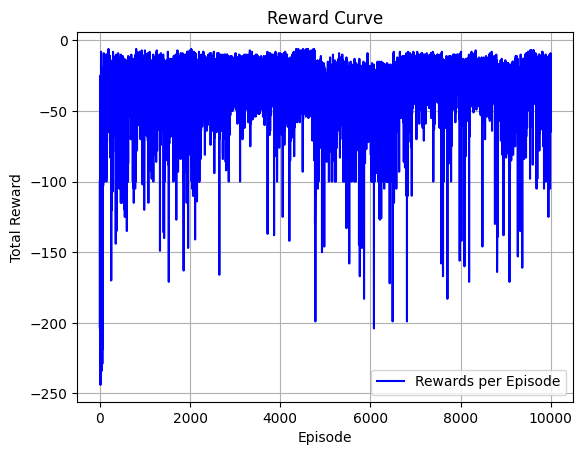

In [ ]:

plt.plot(reward, label="Rewards per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Curve")
plt.legend()
plt.grid()
plt.show()

2. Plot the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).

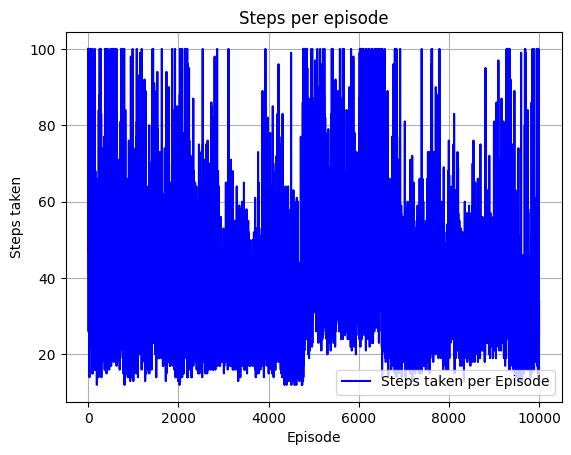

In [ ]:

plt.plot(steps, label="Steps taken per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Steps taken")
plt.title("Steps per episode")
plt.legend()
plt.grid()
plt.show()

3. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.

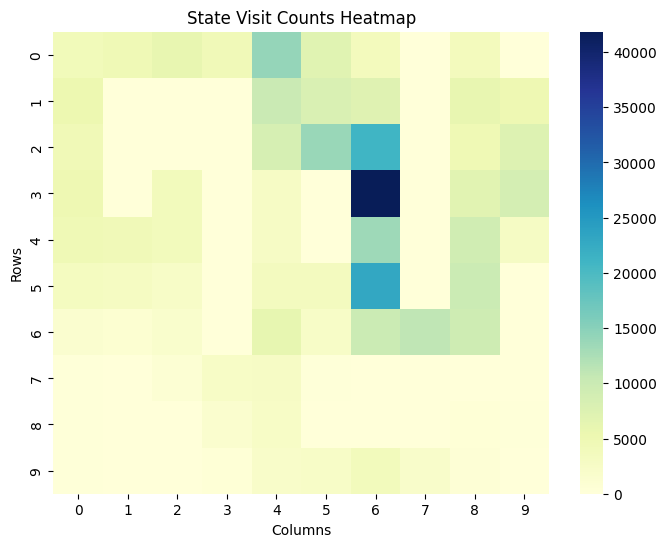

In [ ]:

grid_visits = state_visits.reshape((env.num_rows, env.num_cols))
plt.figure(figsize=(8, 6))
sns.heatmap(grid_visits, cmap="YlGnBu", annot=False, fmt="d")
plt.title("State Visit Counts Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

4. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.

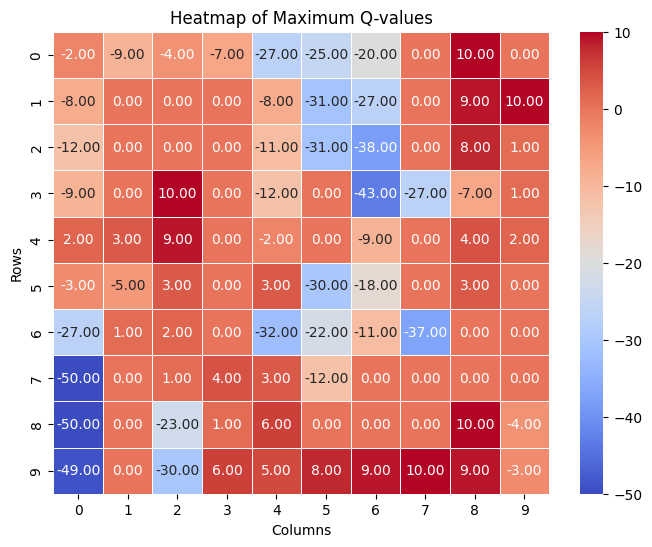

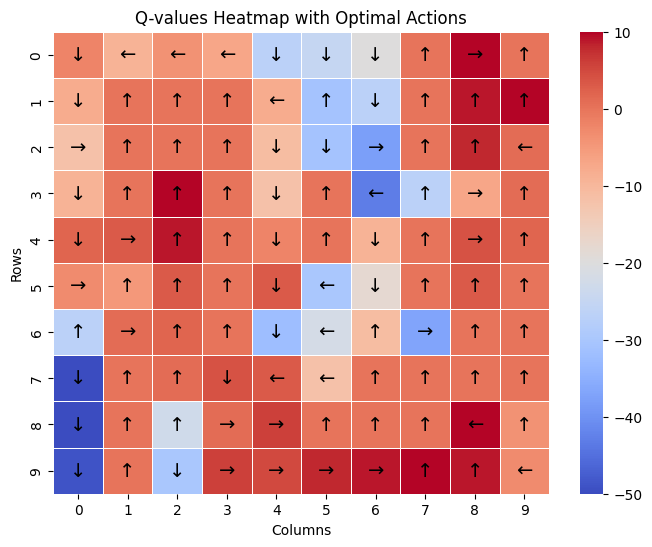

In [ ]:

# Get optimal action for each state (argmax over actions)
optimal_actions = np.argmax(Q, axis=1)

# Compute maximum Q-value per state
max_Q_values = np.max(Q, axis=1)

# Reshape into grid
Q_grid = max_Q_values.reshape((env.num_rows, env.num_cols))
optimal_action_grid = optimal_actions.reshape((env.num_rows, env.num_cols))

plt.figure(figsize=(8, 6))
sns.heatmap(Q_grid, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Maximum Q-values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


# Define action symbols
action_symbols = {0: "↑", 3: "→", 1: "↓", 2: "←"}

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Q_grid, cmap="coolwarm", annot=False, linewidths=0.5)

# Overlay optimal actions
for i in range(env.num_rows):
    for j in range(env.num_cols):
        action = optimal_action_grid[i, j]
        ax.text(j + 0.5, i + 0.5, action_symbols[action], ha="center", va="center", color="black", fontsize=14)

plt.title("Q-values Heatmap with Optimal Actions")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

###  Configuration id 12

#### Configuration Parameters
Learning algorithm = Q-Learning

Wind = False

Start State = (0,4)

Value of $p$ = 0.7

Exploration strategy = softmax

Train the agent

In [ ]:


env.start_state=np.array([[0,4]])
env.p_good_trans=0.7
env.wind=False

def parallel_Qlearning(env, num_episodes, alpha, gamma, temp, num_runs,tuning):
    """Parallel execution of Q-Learning runs using multiprocessing."""
    with mp.Pool(mp.cpu_count()) as pool:
        results = pool.starmap(q_learning_softmax, [(env, num_episodes, alpha, gamma, temp, tuning)] * num_runs)
    if not tuning:
        return results[0][0],results[0][1],results[0][2],results[0][3]
    else:
        return np.mean(results, axis=0)  # Average across runs


# Hyperparameters
num_runs = 100
coarse_episodes = 170
fine_tune_episodes = 1700
top_k_ratio = 0.1

# Store results from coarse search
top_configs = []

# Coarse Search to filter obviously bad configurations
for alpha in learning_rate:
    for gamma in discount_factor:
        for temp in temperature:
            reward = parallel_Qlearning(env, coarse_episodes, alpha, gamma, temp, num_runs,True)
            reward_cumulative = np.sum(reward)
            top_configs.append((reward_cumulative, alpha, gamma, temp))

# Sort and keep the top 10%
top_configs = np.array(top_configs)
top_configs = top_configs[top_configs[:, 0].argsort()[::-1]][:int(len(top_configs) * top_k_ratio)]

# Fine-Tuning on Best Configurations
max_reward, max_alpha, max_gamma, max_temp = -float('inf'), 0, 0, 0

for reward_cumulative, alpha, gamma, temp in top_configs:
    reward = parallel_Qlearning(env, coarse_episodes, alpha, gamma, temp, num_runs,True)
    reward_cumulative = np.sum(reward)

    if reward_cumulative > max_reward:
        max_reward, max_alpha, max_gamma, max_temp = reward_cumulative, alpha, gamma,temp

print("Best Parameters:", max_alpha, max_gamma, max_temp)

num_episodes=10000
Q,reward,steps,state_visits = parallel_Qlearning(env, num_episodes, max_alpha, max_gamma,max_temp,1,False)  # Train QLearning

Best Parameters: 1.0 1.0 0.01


1. Plot reward curves (during the training phase with the best hyperparameters).

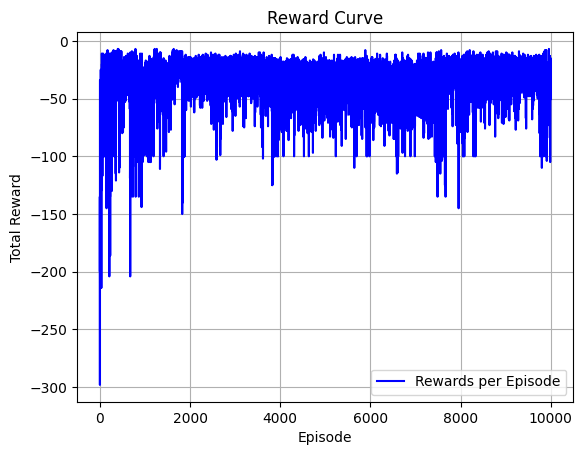

In [ ]:

plt.plot(reward, label="Rewards per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Curve")
plt.legend()
plt.grid()
plt.show()

2. Plot the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).

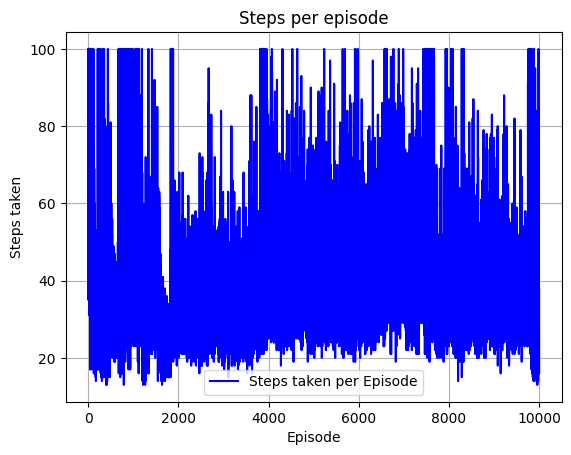

In [ ]:

plt.plot(steps, label="Steps taken per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Steps taken")
plt.title("Steps per episode")
plt.legend()
plt.grid()
plt.show()

3. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.

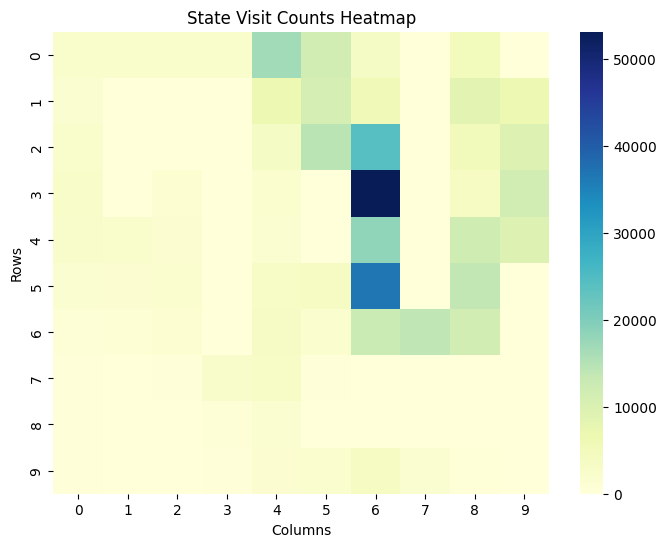

In [ ]:

grid_visits = state_visits.reshape((env.num_rows, env.num_cols))
plt.figure(figsize=(8, 6))
sns.heatmap(grid_visits, cmap="YlGnBu", annot=False, fmt="d")
plt.title("State Visit Counts Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

4. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.

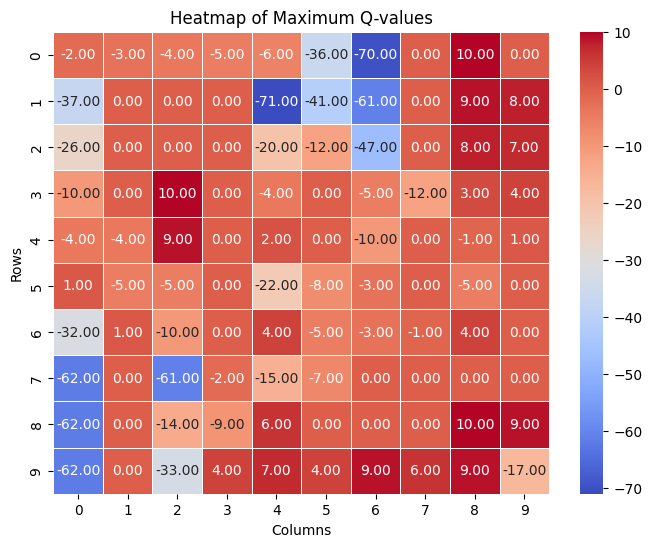

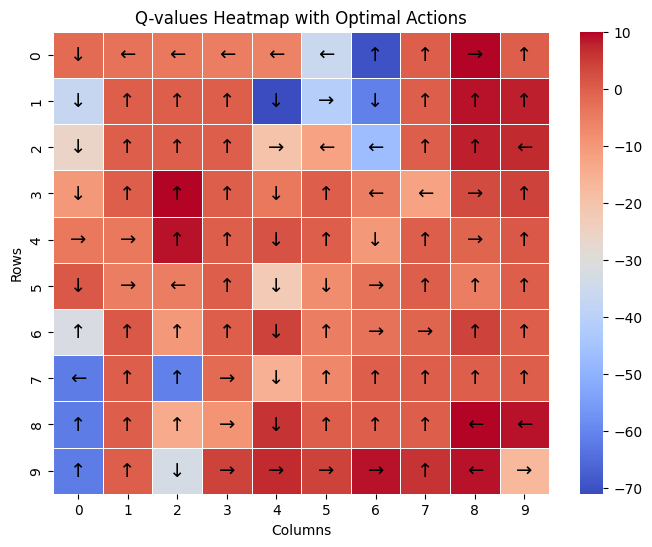

In [ ]:

# Get optimal action for each state (argmax over actions)
optimal_actions = np.argmax(Q, axis=1)

# Compute maximum Q-value per state
max_Q_values = np.max(Q, axis=1)

# Reshape into grid
Q_grid = max_Q_values.reshape((env.num_rows, env.num_cols))
optimal_action_grid = optimal_actions.reshape((env.num_rows, env.num_cols))

plt.figure(figsize=(8, 6))
sns.heatmap(Q_grid, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Maximum Q-values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


# Define action symbols
action_symbols = {0: "↑", 3: "→", 1: "↓", 2: "←"}

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Q_grid, cmap="coolwarm", annot=False, linewidths=0.5)

# Overlay optimal actions
for i in range(env.num_rows):
    for j in range(env.num_cols):
        action = optimal_action_grid[i, j]
        ax.text(j + 0.5, i + 0.5, action_symbols[action], ha="center", va="center", color="black", fontsize=14)

plt.title("Q-values Heatmap with Optimal Actions")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

###  Configuration id 13

#### Configuration Parameters
Learning algorithm = Q-Learning

Wind = False

Start State = (3,6)

Value of $p$ = 1

Exploration strategy = ϵ -greedy

Train the agent

In [ ]:



env.start_state=np.array([[3,6]])
env.p_good_trans=1
env.wind=False

def parallel_Qlearning(env, num_episodes, alpha, gamma, epsilon, num_runs,tuning):
    """Parallel execution of Q-Learning runs using multiprocessing."""
    with mp.Pool(mp.cpu_count()) as pool:
        results = pool.starmap(q_learning_epsilon, [(env, num_episodes, alpha, gamma, epsilon, tuning)] * num_runs)
    if not tuning:
        return results[0][0],results[0][1],results[0][2],results[0][3]
    else:
        return np.mean(results, axis=0)  # Average across runs


# Hyperparameters
num_runs = 100
coarse_episodes = 170
fine_tune_episodes = 1700
top_k_ratio = 0.1

# Store results from coarse search
top_configs = []

# Coarse Search to filter obviously bad configurations
for alpha in learning_rate:
    for gamma in discount_factor:
        for epsilon in e_greedy:
            reward = parallel_Qlearning(env, coarse_episodes, alpha, gamma, epsilon, num_runs,True)
            reward_cumulative = np.sum(reward)
            top_configs.append((reward_cumulative, alpha, gamma, epsilon))

# Sort and keep the top 10%
top_configs = np.array(top_configs)
top_configs = top_configs[top_configs[:, 0].argsort()[::-1]][:int(len(top_configs) * top_k_ratio)]

# Fine-Tuning on Best Configurations
max_reward, max_alpha, max_gamma, max_epsilon = -float('inf'), 0, 0, 0

for reward_cumulative, alpha, gamma, epsilon in top_configs:
    reward = parallel_Qlearning(env, coarse_episodes, alpha, gamma, epsilon, num_runs,True)
    reward_cumulative = np.sum(reward)

    if reward_cumulative > max_reward:
        max_reward, max_alpha, max_gamma, max_epsilon = reward_cumulative, alpha, gamma, epsilon

print("Best Parameters:", max_alpha, max_gamma, max_epsilon)

num_episodes=10000
Q,reward,steps,state_visits = parallel_Qlearning(env, num_episodes, max_alpha, max_gamma,max_epsilon,1,False)  # Train SARSA


Best Parameters: 1.0 1.0 0.001


1. Plot reward curves (during the training phase with the best hyperparameters).

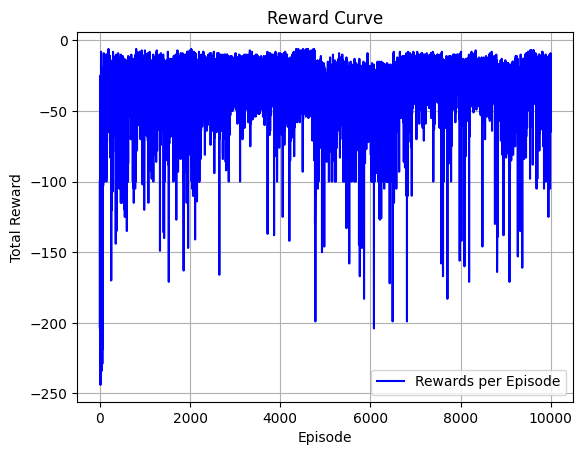

In [ ]:

plt.plot(reward, label="Rewards per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Curve")
plt.legend()
plt.grid()
plt.show()

2. Plot the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).

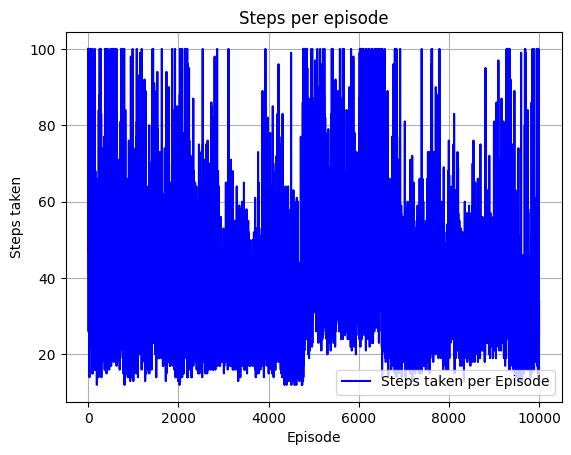

In [ ]:

plt.plot(steps, label="Steps taken per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Steps taken")
plt.title("Steps per episode")
plt.legend()
plt.grid()
plt.show()

3. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.

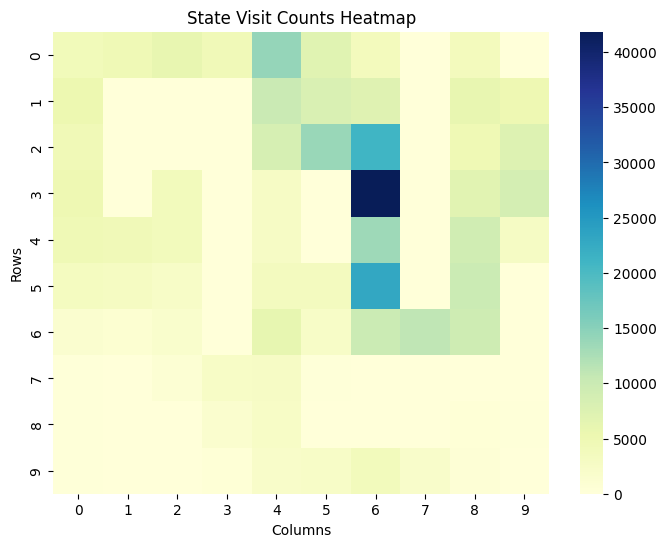

In [ ]:

grid_visits = state_visits.reshape((env.num_rows, env.num_cols))
plt.figure(figsize=(8, 6))
sns.heatmap(grid_visits, cmap="YlGnBu", annot=False, fmt="d")
plt.title("State Visit Counts Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

4. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.

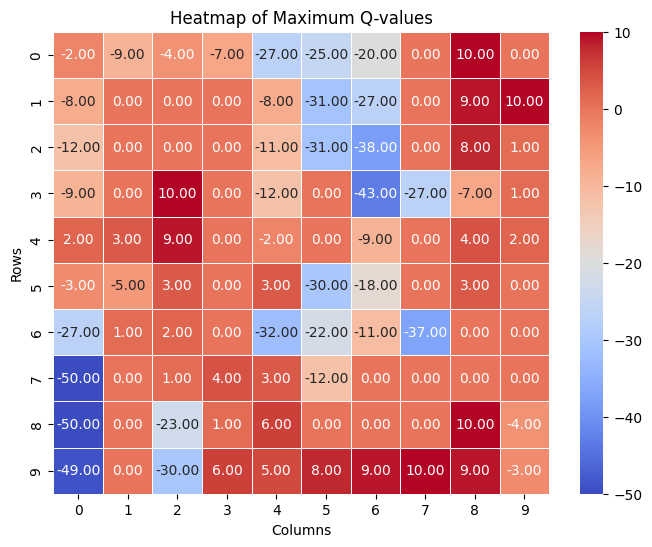

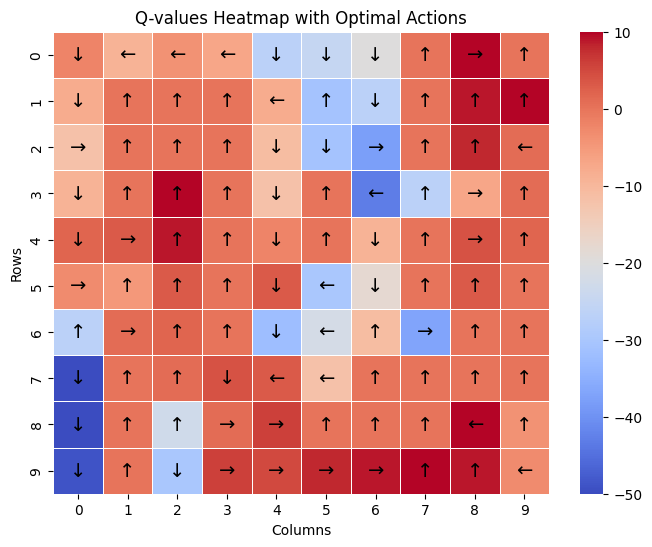

In [ ]:

# Get optimal action for each state (argmax over actions)
optimal_actions = np.argmax(Q, axis=1)

# Compute maximum Q-value per state
max_Q_values = np.max(Q, axis=1)

# Reshape into grid
Q_grid = max_Q_values.reshape((env.num_rows, env.num_cols))
optimal_action_grid = optimal_actions.reshape((env.num_rows, env.num_cols))

plt.figure(figsize=(8, 6))
sns.heatmap(Q_grid, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Maximum Q-values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


# Define action symbols
action_symbols = {0: "↑", 3: "→", 1: "↓", 2: "←"}

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Q_grid, cmap="coolwarm", annot=False, linewidths=0.5)

# Overlay optimal actions
for i in range(env.num_rows):
    for j in range(env.num_cols):
        action = optimal_action_grid[i, j]
        ax.text(j + 0.5, i + 0.5, action_symbols[action], ha="center", va="center", color="black", fontsize=14)

plt.title("Q-values Heatmap with Optimal Actions")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

###  Configuration id 14

#### Configuration Parameters
Learning algorithm = Q-Learning

Wind = False

Start State = (3,6)

Value of $p$ = 1

Exploration strategy = softmax

Train the agent

In [ ]:

env.start_state=np.array([[3,6]])
env.p_good_trans=1
env.wind=False

def parallel_Qlearning(env, num_episodes, alpha, gamma, temp, num_runs,tuning):
    """Parallel execution of Q-Learning runs using multiprocessing."""
    with mp.Pool(mp.cpu_count()) as pool:
        results = pool.starmap(q_learning_softmax, [(env, num_episodes, alpha, gamma, temp, tuning)] * num_runs)
    if not tuning:
        return results[0][0],results[0][1],results[0][2],results[0][3]
    else:
        return np.mean(results, axis=0)  # Average across runs


# Hyperparameters
num_runs = 100
coarse_episodes = 170
fine_tune_episodes = 1700
top_k_ratio = 0.1

# Store results from coarse search
top_configs = []

# Coarse Search to filter obviously bad configurations
for alpha in learning_rate:
    for gamma in discount_factor:
        for temp in temperature:
            reward = parallel_Qlearning(env, coarse_episodes, alpha, gamma, temp, num_runs,True)
            reward_cumulative = np.sum(reward)
            top_configs.append((reward_cumulative, alpha, gamma, temp))

# Sort and keep the top 10%
top_configs = np.array(top_configs)
top_configs = top_configs[top_configs[:, 0].argsort()[::-1]][:int(len(top_configs) * top_k_ratio)]

# Fine-Tuning on Best Configurations
max_reward, max_alpha, max_gamma, max_temp = -float('inf'), 0, 0, 0

for reward_cumulative, alpha, gamma, temp in top_configs:
    reward = parallel_Qlearning(env, coarse_episodes, alpha, gamma, temp, num_runs,True)
    reward_cumulative = np.sum(reward)

    if reward_cumulative > max_reward:
        max_reward, max_alpha, max_gamma, max_temp = reward_cumulative, alpha, gamma,temp

print("Best Parameters:", max_alpha, max_gamma, max_temp)

num_episodes=10000
Q,reward,steps,state_visits = parallel_Qlearning(env, num_episodes, max_alpha, max_gamma,max_temp,1,False)  # Train QLearning

Best Parameters: 1.0 1.0 0.01


1. Plot reward curves (during the training phase with the best hyperparameters).

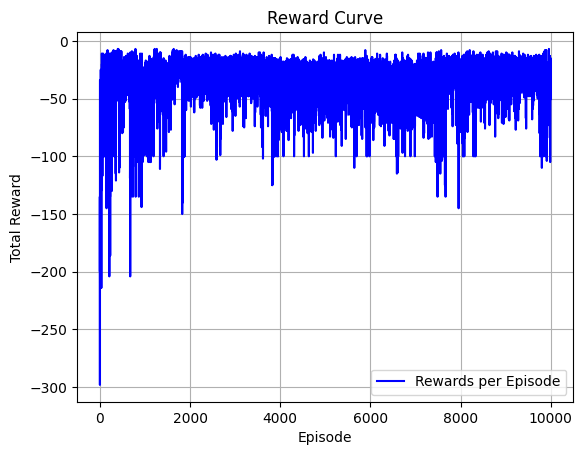

In [ ]:

plt.plot(reward, label="Rewards per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Curve")
plt.legend()
plt.grid()
plt.show()

2. Plot the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).

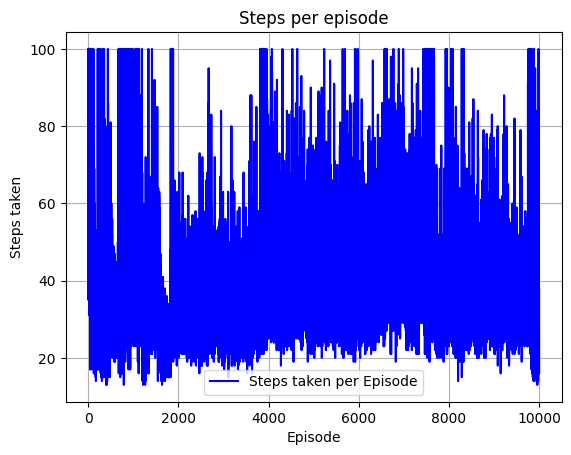

In [ ]:

plt.plot(steps, label="Steps taken per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Steps taken")
plt.title("Steps per episode")
plt.legend()
plt.grid()
plt.show()

3. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.

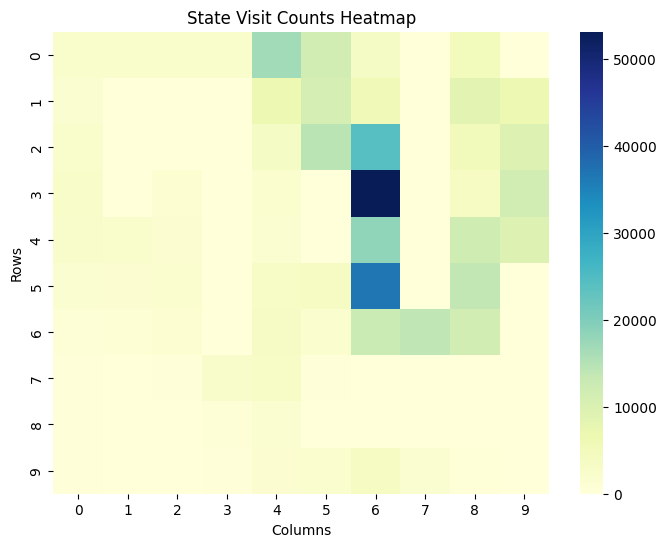

In [ ]:

grid_visits = state_visits.reshape((env.num_rows, env.num_cols))
plt.figure(figsize=(8, 6))
sns.heatmap(grid_visits, cmap="YlGnBu", annot=False, fmt="d")
plt.title("State Visit Counts Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

4. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.

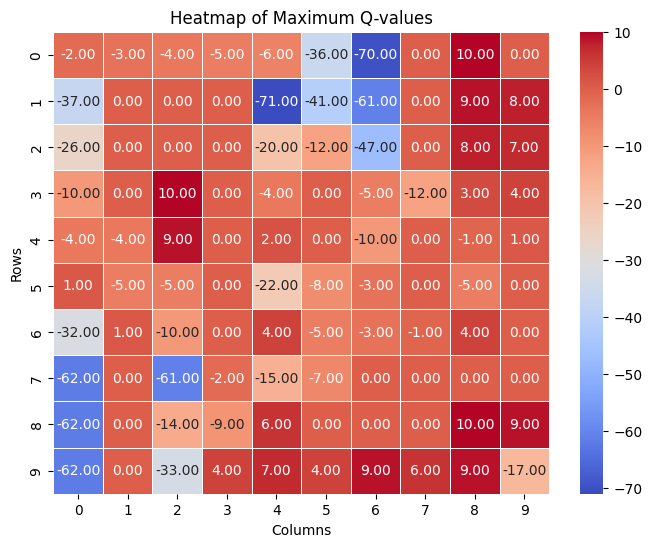

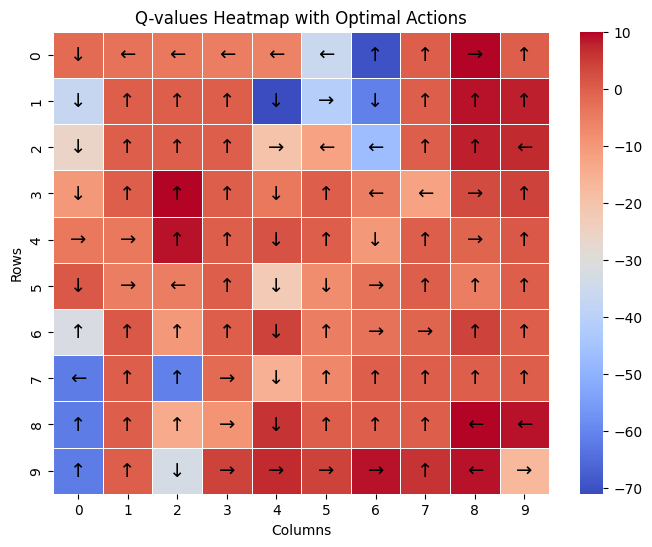

In [ ]:

# Get optimal action for each state (argmax over actions)
optimal_actions = np.argmax(Q, axis=1)

# Compute maximum Q-value per state
max_Q_values = np.max(Q, axis=1)

# Reshape into grid
Q_grid = max_Q_values.reshape((env.num_rows, env.num_cols))
optimal_action_grid = optimal_actions.reshape((env.num_rows, env.num_cols))

plt.figure(figsize=(8, 6))
sns.heatmap(Q_grid, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Maximum Q-values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


# Define action symbols
action_symbols = {0: "↑", 3: "→", 1: "↓", 2: "←"}

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Q_grid, cmap="coolwarm", annot=False, linewidths=0.5)

# Overlay optimal actions
for i in range(env.num_rows):
    for j in range(env.num_cols):
        action = optimal_action_grid[i, j]
        ax.text(j + 0.5, i + 0.5, action_symbols[action], ha="center", va="center", color="black", fontsize=14)

plt.title("Q-values Heatmap with Optimal Actions")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

###  Configuration id 15

#### Configuration Parameters
Learning algorithm = Q-Learning

Wind = False

Start State = (3,6)

Value of $p$ = 0.7

Exploration strategy = ϵ -greedy

Train the agent

In [ ]:



env.start_state=np.array([[3,6]])
env.p_good_trans=0.7
env.wind=False

def parallel_Qlearning(env, num_episodes, alpha, gamma, epsilon, num_runs,tuning):
    """Parallel execution of Q-Learning runs using multiprocessing."""
    with mp.Pool(mp.cpu_count()) as pool:
        results = pool.starmap(q_learning_epsilon, [(env, num_episodes, alpha, gamma, epsilon, tuning)] * num_runs)
    if not tuning:
        return results[0][0],results[0][1],results[0][2],results[0][3]
    else:
        return np.mean(results, axis=0)  # Average across runs


# Hyperparameters
num_runs = 100
coarse_episodes = 170
fine_tune_episodes = 1700
top_k_ratio = 0.1

# Store results from coarse search
top_configs = []

# Coarse Search to filter obviously bad configurations
for alpha in learning_rate:
    for gamma in discount_factor:
        for epsilon in e_greedy:
            reward = parallel_Qlearning(env, coarse_episodes, alpha, gamma, epsilon, num_runs,True)
            reward_cumulative = np.sum(reward)
            top_configs.append((reward_cumulative, alpha, gamma, epsilon))

# Sort and keep the top 10%
top_configs = np.array(top_configs)
top_configs = top_configs[top_configs[:, 0].argsort()[::-1]][:int(len(top_configs) * top_k_ratio)]

# Fine-Tuning on Best Configurations
max_reward, max_alpha, max_gamma, max_epsilon = -float('inf'), 0, 0, 0

for reward_cumulative, alpha, gamma, epsilon in top_configs:
    reward = parallel_Qlearning(env, coarse_episodes, alpha, gamma, epsilon, num_runs,True)
    reward_cumulative = np.sum(reward)

    if reward_cumulative > max_reward:
        max_reward, max_alpha, max_gamma, max_epsilon = reward_cumulative, alpha, gamma, epsilon

print("Best Parameters:", max_alpha, max_gamma, max_epsilon)

num_episodes=10000
Q,reward,steps,state_visits = parallel_Qlearning(env, num_episodes, max_alpha, max_gamma,max_epsilon,1,False)  # Train SARSA


Best Parameters: 1.0 1.0 0.001


1. Plot reward curves (during the training phase with the best hyperparameters).

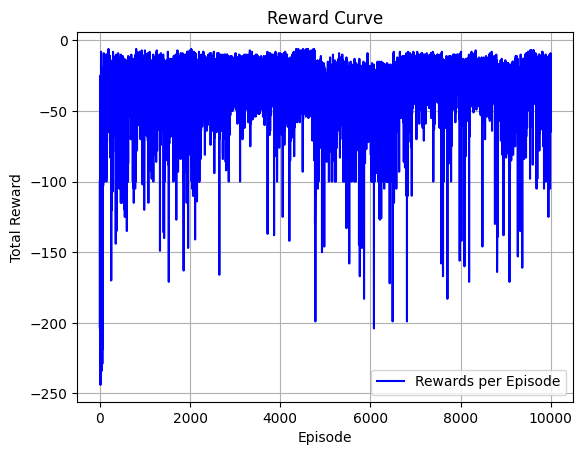

In [ ]:

plt.plot(reward, label="Rewards per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Curve")
plt.legend()
plt.grid()
plt.show()

2. Plot the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).

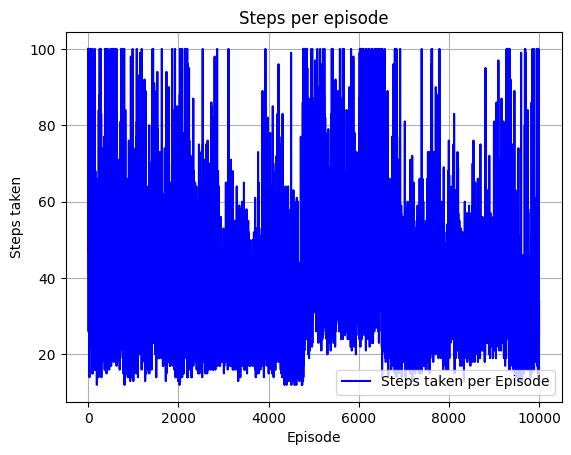

In [ ]:

plt.plot(steps, label="Steps taken per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Steps taken")
plt.title("Steps per episode")
plt.legend()
plt.grid()
plt.show()

3. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.

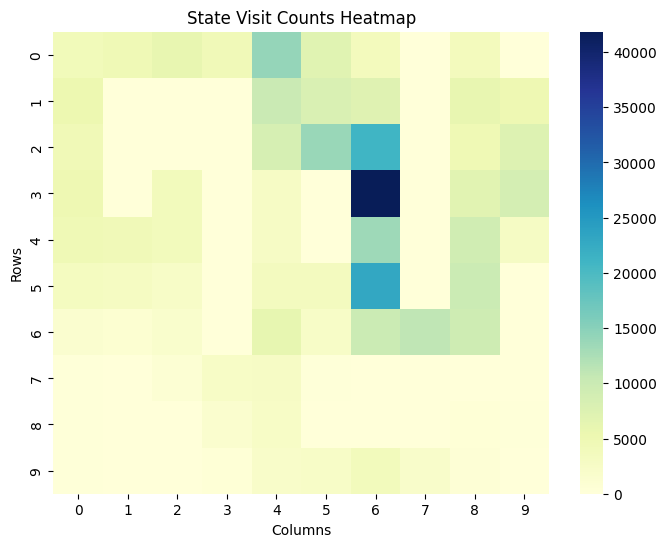

In [ ]:

grid_visits = state_visits.reshape((env.num_rows, env.num_cols))
plt.figure(figsize=(8, 6))
sns.heatmap(grid_visits, cmap="YlGnBu", annot=False, fmt="d")
plt.title("State Visit Counts Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

4. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.

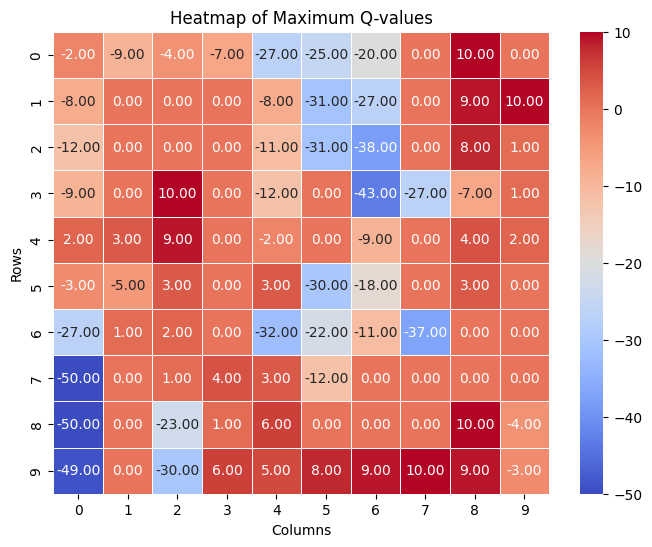

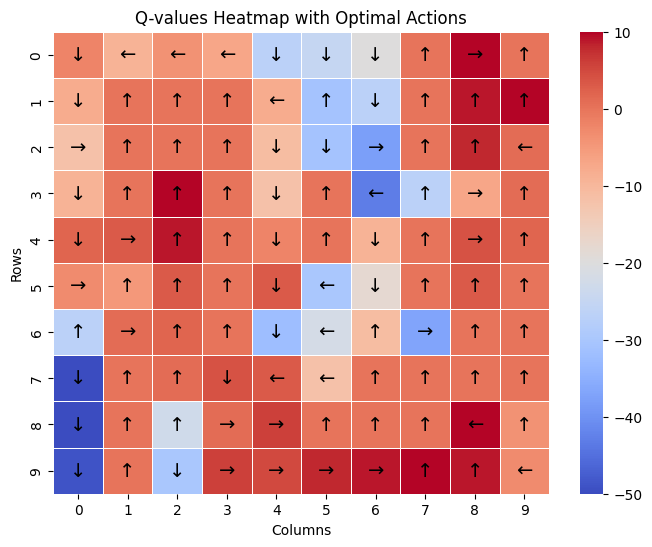

In [ ]:

# Get optimal action for each state (argmax over actions)
optimal_actions = np.argmax(Q, axis=1)

# Compute maximum Q-value per state
max_Q_values = np.max(Q, axis=1)

# Reshape into grid
Q_grid = max_Q_values.reshape((env.num_rows, env.num_cols))
optimal_action_grid = optimal_actions.reshape((env.num_rows, env.num_cols))

plt.figure(figsize=(8, 6))
sns.heatmap(Q_grid, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Maximum Q-values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


# Define action symbols
action_symbols = {0: "↑", 3: "→", 1: "↓", 2: "←"}

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Q_grid, cmap="coolwarm", annot=False, linewidths=0.5)

# Overlay optimal actions
for i in range(env.num_rows):
    for j in range(env.num_cols):
        action = optimal_action_grid[i, j]
        ax.text(j + 0.5, i + 0.5, action_symbols[action], ha="center", va="center", color="black", fontsize=14)

plt.title("Q-values Heatmap with Optimal Actions")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

###  Configuration id 16

#### Configuration Parameters
Learning algorithm = Q-Learning

Wind = False

Start State = (3,6)

Value of $p$ = 0.7

Exploration strategy = softmax

Train the agent

In [ ]:


env.start_state=np.array([[3,6]])
env.p_good_trans=0.7
env.wind=False

def parallel_Qlearning(env, num_episodes, alpha, gamma, temp, num_runs,tuning):
    """Parallel execution of Q-Learning runs using multiprocessing."""
    with mp.Pool(mp.cpu_count()) as pool:
        results = pool.starmap(q_learning_softmax, [(env, num_episodes, alpha, gamma, temp, tuning)] * num_runs)
    if not tuning:
        return results[0][0],results[0][1],results[0][2],results[0][3]
    else:
        return np.mean(results, axis=0)  # Average across runs


# Hyperparameters
num_runs = 100
coarse_episodes = 170
fine_tune_episodes = 1700
top_k_ratio = 0.1

# Store results from coarse search
top_configs = []

# Coarse Search to filter obviously bad configurations
for alpha in learning_rate:
    for gamma in discount_factor:
        for temp in temperature:
            reward = parallel_Qlearning(env, coarse_episodes, alpha, gamma, temp, num_runs,True)
            reward_cumulative = np.sum(reward)
            top_configs.append((reward_cumulative, alpha, gamma, temp))

# Sort and keep the top 10%
top_configs = np.array(top_configs)
top_configs = top_configs[top_configs[:, 0].argsort()[::-1]][:int(len(top_configs) * top_k_ratio)]

# Fine-Tuning on Best Configurations
max_reward, max_alpha, max_gamma, max_temp = -float('inf'), 0, 0, 0

for reward_cumulative, alpha, gamma, temp in top_configs:
    reward = parallel_Qlearning(env, coarse_episodes, alpha, gamma, temp, num_runs,True)
    reward_cumulative = np.sum(reward)

    if reward_cumulative > max_reward:
        max_reward, max_alpha, max_gamma, max_temp = reward_cumulative, alpha, gamma,temp

print("Best Parameters:", max_alpha, max_gamma, max_temp)

num_episodes=10000
Q,reward,steps,state_visits = parallel_Qlearning(env, num_episodes, max_alpha, max_gamma,max_temp,1,False)  # Train QLearning

Best Parameters: 1.0 1.0 0.01


1. Plot reward curves (during the training phase with the best hyperparameters).

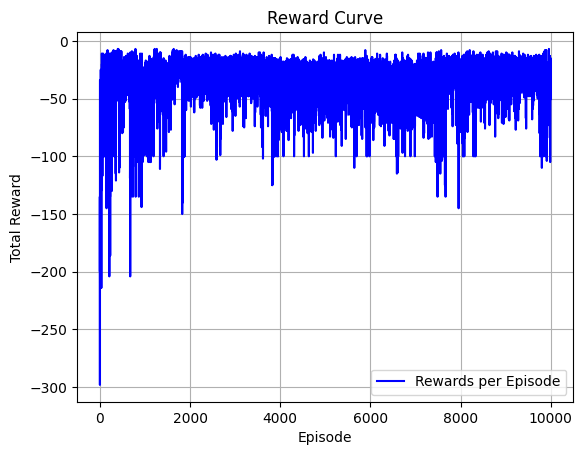

In [ ]:

plt.plot(reward, label="Rewards per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Curve")
plt.legend()
plt.grid()
plt.show()

2. Plot the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).

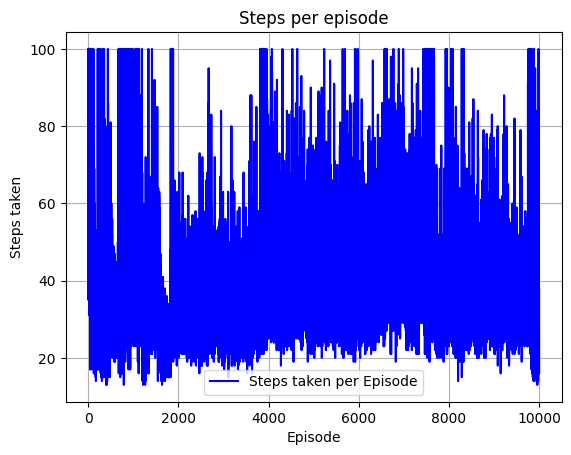

In [ ]:

plt.plot(steps, label="Steps taken per Episode", color='b')
plt.xlabel("Episode")
plt.ylabel("Steps taken")
plt.title("Steps per episode")
plt.legend()
plt.grid()
plt.show()

3. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.

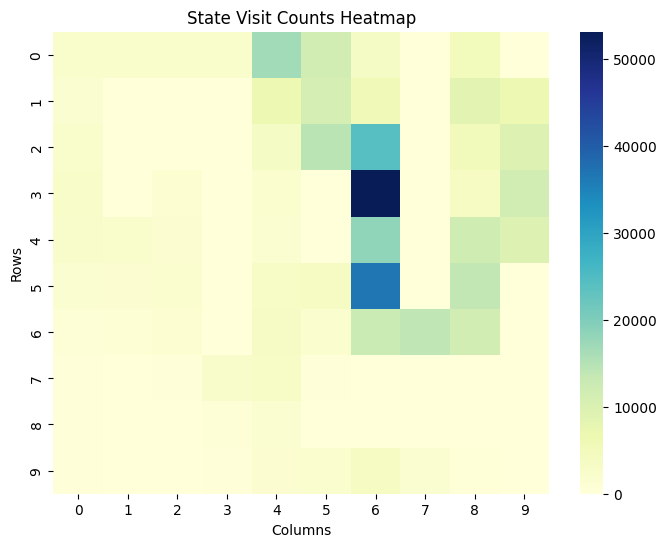

In [ ]:

grid_visits = state_visits.reshape((env.num_rows, env.num_cols))
plt.figure(figsize=(8, 6))
sns.heatmap(grid_visits, cmap="YlGnBu", annot=False, fmt="d")
plt.title("State Visit Counts Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

4. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.

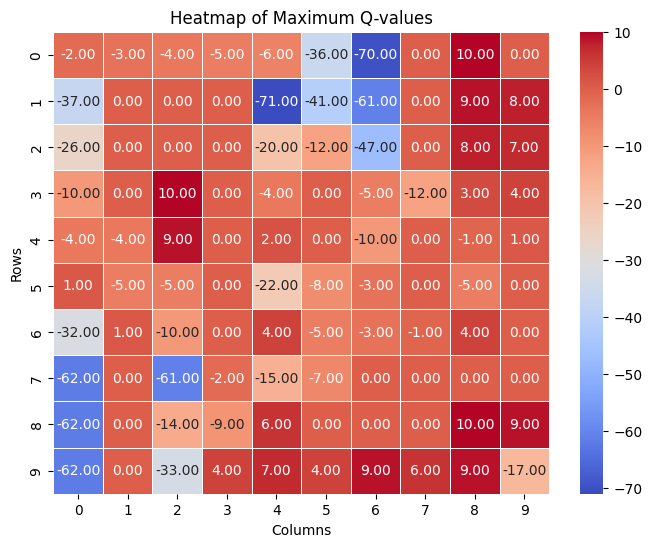

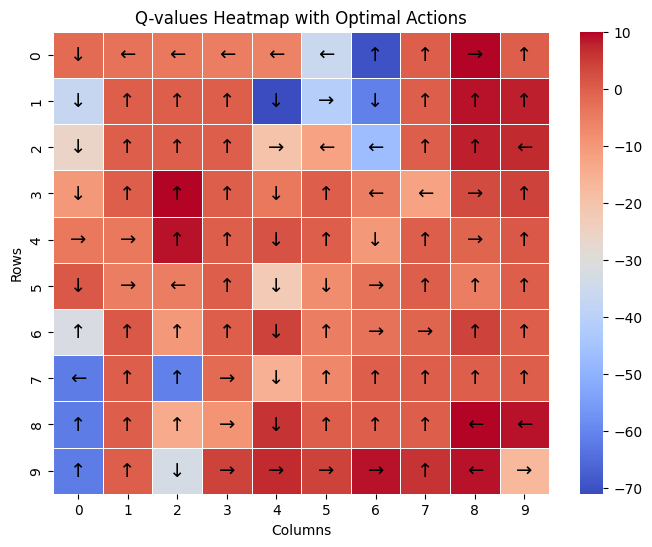

In [ ]:

# Get optimal action for each state (argmax over actions)
optimal_actions = np.argmax(Q, axis=1)

# Compute maximum Q-value per state
max_Q_values = np.max(Q, axis=1)

# Reshape into grid
Q_grid = max_Q_values.reshape((env.num_rows, env.num_cols))
optimal_action_grid = optimal_actions.reshape((env.num_rows, env.num_cols))

plt.figure(figsize=(8, 6))
sns.heatmap(Q_grid, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Maximum Q-values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


# Define action symbols
action_symbols = {0: "↑", 3: "→", 1: "↓", 2: "←"}

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Q_grid, cmap="coolwarm", annot=False, linewidths=0.5)

# Overlay optimal actions
for i in range(env.num_rows):
    for j in range(env.num_cols):
        action = optimal_action_grid[i, j]
        ax.text(j + 0.5, i + 0.5, action_symbols[action], ha="center", va="center", color="black", fontsize=14)

plt.title("Q-values Heatmap with Optimal Actions")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

## Analysis 

### SARSA 

 1. Provide a written description of the policy learnt, explaining the behavior of the agent, and the choice of hyperparameters.

 Answer: In SARSA, both the e-greedy and softmax strategies led to different policies. In e-greedy, most of the state visits were to the goal state [2,2], for which it found a clear and direct path towards, always taking the path to the left of the start state. Meanwhile, the softmax strategy often led to the goal state at [0,9], which it seems to be better capable of doing in the absence of wind. This happened irrespective of the start state. In terms of rewards gathered, e-greedy seems to be gathering more reward than softmax strategy. The Q action state values seems to be taking higher values at both extremes for softmax than e-greedy. The lowest values for softmax seems to be much much smaller than those of e-greedy. There are high Q values like 10 and 9 close to every goal state for softmax, whereas for e-greedy seems to have lower Q values near goal states. The number of steps needed also is lower for e-greedy when compared with softmax. Overall, epsilon greedy is giving better performance than softmax.

The overall better performance of e-greedy can be atrributed to the path that it generally chooses. The e-greedy approach chose the path to goal state [2,2] which has no restart state which has a reward of -100. So since e-greedy is generally less exploratory than softmax, it consistently chose the path that was established to be the most rewarding path. Whereas softmax being more exploratory, chose the path to the right, which has two goal states.Because of these two goal states, the right side of the grid was favoured since the right side gave good reward and the softmax favoured the actions on this side by a proportionate probability.The e-greedy's high probability response to a single high reward action lead it to being less exploratory.The general behaviour of both the type of strategies were based on this idea. Softmax might be showing higher q values at multiple states, because of the exploratory nature of it due to which it explores more actions.

The hyper parameters were chosen after an initial coarse sweep which removed all the obviously bad configurations, then finetuning using high number of episodes from among the top 10 percent hyper parameters to choose the best hyper parameters. Alpha=0.1(low to moderate),gamma= 0.9(high) and epsilon=0.001(low) was a highly frequently occuring set of parameters for epsilon greedy. The lower alpha value points to the direction that the agent learns slowly. The high gamma value shows that the agent prioritizes long term reward over short term ones. The low epsilon shows that the agent chose to exploit more than explore. Alpha =1.0(very high), gamma=1.0(high) and temperature=0.01(very low) was a frequently occuring best parameters among the soft max strategy. The high alpha values show the agent learns faster and replaces old values with new values quickly.The high gamma value shows that the agent values future rewards just as much as immediate rewards. The low temperature shows that the agent is more greedy than exploratory. Both softmax and e-greedy agents seem to be preferring highly exploiting actions. This could be dues to the gridworld being full of obstacles and high negative rewards.

 2. This description should also provide information about how the behavior changes with and without the wind, for different levels of stochasticity and for different start states.

 Answer: In the case of wind, the rewards gathered was much higher for when there was no wind. In all the variations of SARSA, the presence of wind lead to lesser reward in both average and minimum reward. For example in one instance, the presence of wind dropped the minimum reward to -300 from -250. The number of steps till goal reduced by almost half in some cases in the absence of wind. There was an almost half reduction of rewards in the presence of wind. This could be attributed to the adding of uncertainity to the choices. The wind caused the best action chosen to change and hence lead to lesser results. Both the agents seem to be better able to guide in the absence of wind. The stochastic nature of wind deviates the agent from ideal behavior.The agent chooses an action which would be good but the presence of wind could have changed it to something different. In the case of SARSA, there is only one level of stochasticity where p=1 always.

There are two different start states-[0,4] and [3,6]. [3,6] is next to a restart state. Because of this [3,6] is expected to suffer a drop in performace. But it is not too much of a difference in terms of reward or Q values or steps taken, the difference is small. The goal state at [2,2] is closer to the start state [0,4] and the goal state at [0,9] is closer to start state [3,6]. The relatively closer values for both the start points could be attributed to the fact that the path between both of the start states was pretty open, so locations reachable by either state was also reachable similarly by the other state. The path selected by e-greedy and softmax remains the same in both the cases, that is e-greedy tends to choose the goal state at [2,2] in both start points and softmax chooses [0,9] in both the start points.

Optional Comments: SARSA doesn't seem to be forcing epsilon greedy to explore much. This can be seen in the trajectory of epsilon greedy being highly one sided. The path taken is mostly to the goal state [2,2]. The presence of wind highly affected the training of the agent. This could be attributed to the fact that if a low probability action is chosen with a probability close to zero, then wind changes the direction with a high probability. The stochastic nature of wind is very high. It interfered much with training. The softmax seems to have explored the right side goal, even though it has more obstacles, possibly because of the presence of multiple good actions due to the presence of two goal states to the right side.

### Q Learning 

1. Provide a written description of the policy learnt, explaining the behavior of the agent, and the choice of hyperparameters.

 Answer: In Q-Learning, the ε-greedy and softmax strategies resulted in more similar policies compared to SARSA. With ε-greedy, the agent predominantly navigated towards the goal state at [0,9], unlike in SARSA ,favoring the right-side path from the start state. The [2,2] goal state is also visited often unlike in SARSA where the visits were very one sided. The softmax strategy followed the same trend of leaning toward the goal state at [0,9], regardless of the starting position, though it is visiting the [2,2] more often than in SARSA. In terms of performance, softmax seems to be accumulating similar rewards compared to e-greedy, unlike in the case of SARSA. But softmax exibits more minimum reward of -300 compared to -250 of e-greedy. In terms of steps needed to reach goal, in early stages, softmax seems to take lesser steps but later on e-greedy takes lesser steps to reach goal. In case of Q values, softmax seems to have extreme, both positive and negative, values compared to epsilon greedy. The softmax strategy seems to be showing more positive values overall compared to e-greedy.The values vary highly in both the cases.  Softmax looks to be the more efficient strategy overall.

Unlike in the case of SARSA, in Q Learning, softmax seems to be a better working strategy. Both the start points seems to be preferring the right side goal state more. This could be because the maximum Q estimate value is chosen to correct the estimates unlike in SARSA ,where we sample the next action. This taking the maximum value leads to preference of the right side goal state[0,9] because of the presence of two goal states in the right side. Q Learning observes the highest estimate on the right side because of this. The epsilon greedy stategy because of its lower exploration, finds it harder to navigate the right side of the grid whereas the softmax because of better exploration does it better. The softmax strategy gets more extreme values in calculating Q, both positive and negative. This could be because of its higher exploration showing results at higher reward areas(near goal states) and showing lower outputs at low reward areas (boundary regions , away from goals). The rewards are somewhat similar in both e-greedy and softmax, this could be becasue they seem to be following similar paths unlike  SARSA. The state visits are very close in e-greedy and softmax. The number of steps needed to reach goal state is initally lower for softmax, possibly because it explores more and find goal states earlier. Epsilon geedy catches up later and because of higher exploitation it needs lesser steps to the end of training. Softmax explores even to the end, hence taking more steps than e-greedy to the end.

 The hyperparameters were selected through a two-phase process: an initial coarse sweep to eliminate suboptimal configurations, followed by fine-tuning using a large number of episodes to identify the best-performing parameters.

Here ,alpha=1.0(very high), gamma=1.0(very high) and epsilon=0.001(very low) was the combination obtained in all the cases of epsilon greedy Q learning.
Alpha value of 1.0 shows aggressive learning where old values are replaced at a much higher rate when we get new values. The high gamma value of 1.0 shows that the agent values future rewards as much as immediate rewards. The very low epsilon value of 0.001 shoes almost no exploration, the agent prefer to exploit more.  While for softmax, α = 1.0, γ = 1.0, and a temperature value of 0.01 yielded the best results for all the variations. Alpha and gamma  values for softmax are similar to that of epsilon greedy. The high learning rate shows very fast updates, which could lead to instability in stochastic environment. Just like in epsilon geedy, the newer information overwrites the old information quicker. The high discount factor gamma shows shows higher valuing of future rewards and encourages long time planning. We can see that the hyperparameters turned out to be the same for all the similar variations in Q Learning as opposed to SARSA ,where sometimes, different hyperparameters were observed. This could be maybe be attributed to the fact that in Q Learning, the maximun action estimate is used for update, whereas in SARSA, it is sampled.

2. This description should also provide information about how the behavior changes with and without the wind, for different levels of stochasticity and for different start states.

 Answer: The wind is set to false in Q Learning.  In Q Learning, there are two levels of stochasticity where p=1 or p=0.7. Both seems to be giving highly similar values in rewards.  The same is happening in states visited and number of steps taken. Q values also seem to be giving similar values. This could be because the p value of 0.7 is high and might make lesser changes. The overall stochasticity might be keeping the effect of p value in touch. In the case of SARSA, the presence of wind proved drastic with its random nature. But the p value of 0.7 doesn't seem to be making that much of an issue. This could be because the effect of wind is more probable in low probability actions and this could have made lots of bad transitions from bad actions, wheras the p=0.7 is moving in the expected direction most of the time.

There are two different start states-[0,4] and [3,6]. . But there is not too much of a difference in terms of reward or Q values or steps taken, the difference is very small. This could be due to the open path between both the start states and the lower differentiation between both the start states. This closeness of the start states to one another looks to be playing a big role in why they are showing similar performance. The high negative reward of the restart state near [3,6] might have already classified that action as low reward and later on might not have much effect on the trajectory. The path selected by e-greedy and softmax remains the same in both the cases, that is e-greedy and softmax  tends to choose the goal state at [0,9] in both start points. This could be because Q-Learning corrects based on the best estimate and the best estimate will be higher in the right side path due to the presence of two goal states. But unlike in SARSA, the path chosen is not one sided, as here the [2,2] goal state is also visited a lot of the time.

Optional Comments: In terms of stochasticity, the transition probability of 0.7 doesn't seem to have made much of an impact on the training, unlike the wind in case of SARSA. There seems to have been more exploration in Q-learning than compared to SARSA. This could be because the correction is done using the best estimate, which leaves the door open for more exploration in different states. In SARSA, epsilon greedy was highly exploiting and chose the goal state at [2,2], but in Q-Learning, the goal state preferred was [0,9]. This could be because the two goal states in the right making the maximum estimates to be higher and Q-learning adjusts based on the maximum estimates leading to more exploration of the right side by epsilon greedy. even with the low exploratory values of epsilon greedy, the right side was chosen. In case of softmax, it countinued the trend of exploring the right side. So in conclusion, Q-Learning looks to be more exploratory than SARSA for this grid world. Softmax being more exploratory prefers Q-Learning and epsilon greedy being more exploiting prefers SARSA